# Deep Convolutional Gaussian Process
## for Extragalactic Globular Cluster Detection

<br>

**AI In Industry Assignment**  

| Name | Email |
| :--- | :--- |
| Ludovico Gorrieri | ludovico.gorrieri@studio.unibo.it |
| Ashmi Prasad | ashmi.prasad@studio.unibo.it |
| Grigorii Kolosov | grigorii.kolosov@studio.unibo.it |

Based on: Dold & Fahrion (2022), *A&A* 663, A81

---

*Data:* HST/ACS — F475W (g) + F850LP (z) · 20 × 20 px cutouts  
*Clusters:* Virgo (VCC) · Fornax (FCC)

## What are Globular Clusters?

Compact, gravitationally bound systems of **10⁴–10⁶ stars**, among the oldest objects in the universe (~10–13 Gyr)

<br>

> **Why do astronomers care?**  
> GCs are *fossils* of early galaxy formation. Their positions, velocities and chemical composition encode how their host galaxy was assembled — including ancient mergers that left no other trace.

### Key observational properties

| Property | Typical value | Physical meaning |
|----------|---------------|-----------------|
| Apparent size | Slightly extended vs. point source | Resolved at HST resolution |
| g − z colour | 0.7 – 1.7 mag | Reflects stellar metallicity |
| Magnitude | 22 – 27 mag (ACS) | Old stellar population |
| Concentration index | CI > 1.3 | Central brightness peak |

## The Detection Problem

We have HST images of two galaxy clusters with **~85,000 candidate sources**.  
Only ~18,000 are genuine GCs.

<br>

### Why is this hard?

- Background galaxies, foreground stars, and star-forming knots all look similar
- Traditional selection requires **manual cuts** in magnitude × colour × concentration space
- Cuts must be re-tuned for every new survey / distance

### What the paper (Dold & Fahrion 2022) showed

A **standard CNN** trained on HST cutouts achieves:
- TPR ≈ **90–94 %** (fraction of real GCs recovered)
- FDR ≈ **6–8 %** (fraction of detections that are impostors)

*This notebook replaces the CNN with a **Deep Convolutional Gaussian Process**,  
gaining calibrated uncertainty and a richer explainability surface.*

## The Data

Each source → **20 × 20 px two-channel image cutout**

| Channel | HST filter | Wavelength | What it captures |
|---------|-----------|------------|-----------------|
| **g** (ch 0) | F475W | ~475 nm | Blue light — traces younger, metal-poor stars |
| **z** (ch 1) | F850LP | ~850 nm | Near-IR — traces older, metal-rich stars |

<br>

Both channels together encode the **g − z colour**, the most physically diagnostic GC feature.

## Why g − z Colour Matters

GC systems around massive galaxies display a robust **bimodal colour distribution**:

```
         metal-poor         metal-rich
         (blue GCs)         (red GCs)
             │                  │
    ──────── ▼ ──────────────── ▼ ────────────→  g − z
           ~0.9               ~1.4
```

### Physical interpretation

| Peak | g − z | Where found | Origin |
|------|-------|-------------|--------|
| **Blue** (metal-poor) | ~0.9 | Outer halo | Formed in low-mass progenitors before assembly |
| **Red** (metal-rich) | ~1.4 | Inner regions | Formed in-situ during main star-formation epoch |

<br>

> If our model is genuinely recognising GCs, its detected catalogue should **recover this bimodality**.  
> False positives and missed GCs should cluster in the overlap region — we check this explicitly.

## Dataset & Class Imbalance

| Split | Samples | Notes |
|-------|---------|-------|
| Train | ~60 k | 70 % of merged VCC + FCC |
| Val   | ~8 k  | 10 % |
| Test  | ~17 k | 20 % |

**Class ratio: ~1 : 3.4** (GC : non-GC)

<br>

> **Previous approach:** downsample majority class to match minority → **discards ~45 k examples**  
> **Our approach:** keep all data, handle imbalance via **weighted loss** (see §5)

The downsampling bug was in the original notebook: .sample(min_class_size) without replace=True.

In [1]:
%cd ..
!git clone https://github.com/dodo47/GCDetection

from typing import List, Tuple, Dict, Optional
import io
import traceback
import contextlib
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.distributions import Normal
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
import optuna
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from utils import data

KMEANS_CACHE_DIR = Path("kmeans_cache")
KMEANS_CACHE_DIR.mkdir(exist_ok=True)
print(f"KMeans cache dir: {KMEANS_CACHE_DIR.resolve()}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Telegram helpers ──────────────────────────────────────────────────────────

def _get_token(file_path="telegram_token.txt"):
    with open(file_path) as f:
        token, chat_id = f.read().strip().split(",")
    return token, chat_id

token, chat_id = _get_token()


def send_telegram_msg(token: str, chat_id: str, text: str) -> dict:
    """Send a plain-text Telegram message (Markdown supported)."""
    url = f"https://api.telegram.org/bot{token}/sendMessage"
    try:
        r = requests.post(url, data={"chat_id": chat_id,
                                      "text": text,
                                      "parse_mode": "Markdown"})
        return r.json()
    except Exception as e:
        print(f"Telegram sendMessage failed: {e}")


def send_telegram_photo(token: str, chat_id: str,
                        fig=None, caption: str = "") -> dict:
    """
    Send the current (or given) matplotlib figure to Telegram as a photo.

    Parameters
    ----------
    token, chat_id : Telegram credentials.
    fig            : matplotlib Figure object.  If None the current figure
                     (plt.gcf()) is used.
    caption        : Caption shown under the image (max 1024 chars).
    """
    if fig is None:
        fig = plt.gcf()

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)

    url = f"https://api.telegram.org/bot{token}/sendPhoto"
    try:
        r = requests.post(url,
                          data={"chat_id": chat_id, "caption": caption[:1024]},
                          files={"photo": ("plot.png", buf, "image/png")})
        return r.json()
    except Exception as e:
        print(f"Telegram sendPhoto failed: {e}")
    finally:
        buf.close()


@contextlib.contextmanager
def notify_on_error(token: str, chat_id: str, cell_name: str):
    """
    Context manager that catches any exception, sends a Telegram alert with
    the full traceback, then re-raises so the kernel still stops.

    Usage:
        with notify_on_error(token, chat_id, "Training loop"):
            ... cell code ...
    """
    try:
        yield
    except Exception as exc:
        tb = traceback.format_exc()
        msg = (
            f"🚨 *Notebook error* in *{cell_name}*\n\n"
            f"`{type(exc).__name__}: {exc}`\n\n"
            f"```\n{tb[-1500:]}\n```"   # Telegram cap: 4096 chars total
        )
        send_telegram_msg(token, chat_id, msg)
        raise   # re-raise so the notebook stops cleanly

/home/ludi/Documents/Uni/magistrale/AII/AII-Assignment
fatal: destination path 'GCDetection' already exists and is not an empty directory.


KMeans cache dir: /home/ludi/Documents/Uni/magistrale/AII/AII-Assignment/kmeans_cache
Using device: cuda


Total samples : 82,026
  GC  (pos=1) : 18,151  (22.1 %)
  non-GC (0)  : 63,875  (77.9 %)

Class weights → non-GC: 0.642, GC: 2.260


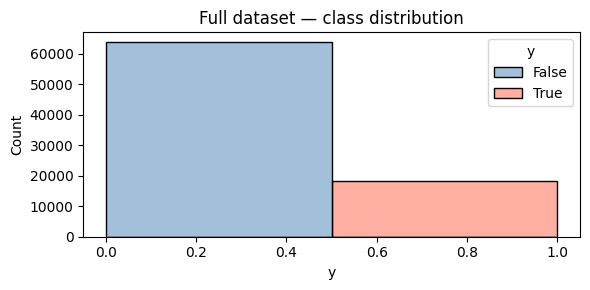

In [2]:
with notify_on_error(token, chat_id, "Data loading"):
    FCC, VCC = data.prepare_data()
    all_frames = pd.concat((FCC, VCC), ignore_index=True)
    all_frames = all_frames[~all_frames.frame.apply(lambda x: np.isnan(x).any())]

    counts = all_frames['y'].value_counts()
    n_neg, n_pos = int(counts[False]), int(counts[True])
    total = n_neg + n_pos
    print(f"Total samples : {total:,}")
    print(f"  GC  (pos=1) : {n_pos:,}  ({100*n_pos/total:.1f} %)")
    print(f"  non-GC (0)  : {n_neg:,}  ({100*n_neg/total:.1f} %)")

    w_pos = total / (2 * n_pos)
    w_neg = total / (2 * n_neg)
    CLASS_WEIGHTS = torch.tensor([w_neg, w_pos], dtype=torch.float32).to(device)
    print(f"\nClass weights → non-GC: {w_neg:.3f}, GC: {w_pos:.3f}")

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.histplot(data=all_frames, x="y", bins=2, hue="y",
                 palette=['steelblue', 'tomato'], ax=ax)
    ax.set_title("Full dataset — class distribution")
    plt.tight_layout()
    send_telegram_photo(token, chat_id, fig,
        caption=f"✅ Data loaded\n"
                f"Total: {total:,}  |  GC: {n_pos:,} ({100*n_pos/total:.1f}%)  "
                f"|  non-GC: {n_neg:,} ({100*n_neg/total:.1f}%)")
    plt.show()

In [3]:
with notify_on_error(token, chat_id, "Data splits"):
    def make_splits(df, train_frac=0.70, val_frac=0.10, seed=42):
        df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
        n = len(df)
        n_train = int(n * train_frac)
        n_val   = int(n * val_frac)
        return df[:n_train], df[n_train:n_train+n_val], df[n_train+n_val:]

    train_df, val_df, test_df = make_splits(all_frames)
    print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")

    fcc_df = FCC[~FCC.frame.apply(lambda x: np.isnan(x).any())]
    vcc_df = VCC[~VCC.frame.apply(lambda x: np.isnan(x).any())]

Train: 57,418  |  Val: 8,202  |  Test: 16,406


In [4]:
with notify_on_error(token, chat_id, "Dataset & DataLoaders"):
    class FrameDataset(Dataset):
        """Two-channel (g, z) image dataset for GC classification."""
    
        def __init__(self, df: pd.DataFrame, transform=None):
            self.frames = np.stack(df.frame.values).astype('float32')  # (N, 2, 20, 20)
            self.labels = np.array(df.y, dtype=np.int64)
            self.transform = transform
    
        def __len__(self):
            return len(self.labels)
    
        def __getitem__(self, idx):
            img = self.frames[idx]
            if self.transform:
                ch0 = self.transform(img[0])
                ch1 = self.transform(img[1])
                img = np.stack([ch0, ch1])
            return torch.tensor(img).float(), torch.tensor(self.labels[idx])
    
    
    def make_loader(df, batch_size=64, shuffle=True, num_workers=4):
        return DataLoader(FrameDataset(df), batch_size=batch_size,
                          shuffle=shuffle, num_workers=num_workers, pin_memory=True)
    
    train_dl = make_loader(train_df, shuffle=True)
    val_dl   = make_loader(val_df,   shuffle=False)
    test_dl  = make_loader(test_df,  shuffle=False)

## Gaussian Processes — Intuition

Forget neural networks for a moment.

> A **Gaussian Process** is a probability distribution *over functions*.  
> Instead of learning a single function f(x), we learn a **distribution** over all plausible functions compatible with the data.

### The key idea

- Before seeing data: every smooth function is possible → **wide uncertainty**
- After seeing data: functions that pass near the observations are probable → **narrow uncertainty near data**
- At unseen test points: the GP gives both a **prediction** and a **confidence interval**

This is the fundamental advantage over a CNN: the model knows *how much it doesn't know*.

## Gaussian Processes — Formal Definition

$$f \sim \mathcal{GP}\!\left(m(\mathbf{x}),\; k(\mathbf{x}, \mathbf{x}')\right)$$

Two ingredients:

| Component | Symbol | Role |
|-----------|--------|------|
| Mean function | $m(\mathbf{x})$ | Prior expectation of the function (usually 0) |
| Kernel function | $k(\mathbf{x}, \mathbf{x}')$ | Encodes how similar two inputs are → controls smoothness |

For any finite set of inputs $\mathbf{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_N\}$, the function values are **jointly Gaussian**:

$$p(\mathbf{f} \mid \mathbf{X}) = \mathcal{N}\!\left(\mathbf{f} \;\middle|\; \mathbf{m}(\mathbf{X}),\; K_{\mathbf{X}\mathbf{X}}\right)$$

where $[K_{\mathbf{XX}}]_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ — the **kernel matrix** captures all pairwise similarities.

## The RBF Kernel

We use the **Radial Basis Function (squared-exponential)** kernel:

$$k(\mathbf{x}, \mathbf{x}') = \sigma^2 \exp\!\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

<br>

### Two learnable parameters

| Parameter | Symbol | Effect |
|-----------|--------|--------|
| **Signal variance** | $\sigma^2$ | Overall scale of function variation — how "tall" are the bumps? |
| **Lengthscale** | $\ell$ | How quickly similarity decays with distance — how "wide" are the bumps? |

### Intuition

- **Large $\ell$** → nearby patches look similar → smooth functions → strong generalisation
- **Small $\ell$** → only very close patches are similar → wiggly functions → risk of overfitting
- Both are learned from data in log-space: $\sigma = \text{softplus}(\log\sigma)$, ensuring positivity

## The Scalability Problem

A standard GP trained on $N$ data points costs:

$$O(N^3) \text{ time}, \quad O(N^2) \text{ memory}$$

For our **~60,000 training images** this is completely intractable.

<br>

> ❌ $60{,}000^3 = 2.16 \times 10^{14}$ operations just to invert the kernel matrix

We need **sparse approximation**.

## Inducing Points — The Idea

Instead of conditioning on all $N$ training points, we introduce $M \ll N$ **inducing points** $\mathbf{Z}$:

```
All training data  (~60,000 patches)
         │
         │   too expensive to use directly
         │
         ▼
  Inducing points  (M = 32–256 patches)
         │
         │   GP conditioned only on these
         │
         ▼
   Approximate posterior over all predictions
```

### Key insight

The inducing points act as a **compressed summary** of the training data.  

- They are initialised via **k-means** on real training patches → they start in data-space
- They are then **learned jointly** with all other parameters via gradient descent
- The approximation quality improves with $M$ — more inducing points = more expressive, but $O(M^2)$ cost

## Sparse Variational GP — The Math

We approximate the true posterior with a variational distribution over inducing outputs $\mathbf{u} = f(\mathbf{Z})$:

$$q(\mathbf{u}) = \mathcal{N}(\mathbf{u} \mid \mathbf{m}, \mathbf{S}), \qquad \mathbf{S} = \mathbf{L}_S \mathbf{L}_S^\top$$

- $\mathbf{m} \in \mathbb{R}^{M \times C}$ — variational mean (what the model expects at each inducing point)
- $\mathbf{S} \in \mathbb{R}^{M \times M}$ — variational covariance (full-rank, positive-definite by construction)

### Predictive distribution at a new point $\mathbf{x}^*$

$$q(f^*) = \mathcal{N}\!\left(f^* \;\middle|\; \underbrace{\mathbf{A}\mathbf{m}}_{\text{predicted mean}},\; \underbrace{k_{**} - \mathbf{A}(K_{\mathbf{ZZ}} - \mathbf{S})\mathbf{A}^\top}_{\text{predicted variance}}\right)$$

where $\mathbf{A} = K_{\mathbf{x}^*\mathbf{Z}}\,K_{\mathbf{ZZ}}^{-1}$ — the **interpolation weights** from inducing points to $\mathbf{x}^*$.

> **Cost:** $O(NM^2)$ — tractable! For $M=256, N=60\text{k}$: ~$3.9 \times 10^9$ ops vs $2.16 \times 10^{14}$

## From GP to Convolutional GP

A standard GP takes a **vector** as input.  
Our inputs are **20 × 20 × 2 images** — we need spatial structure.

### The key extension (van der Wilk et al. 2017)

Instead of applying the GP to the whole image, apply it to **every $k \times k$ patch**:

```
Image (B, 2, 20, 20)
       │
       │  extract all overlapping k×k patches
       ▼
Patches (B, N_patches, k²·C_in)   ← each patch is a vector → GP input
       │
       │  apply sparse GP independently to each patch
       ▼
Feature values (B, N_patches, C_out)
       │
       │  arrange back into spatial grid
       ▼
Feature map (B, C_out, H_out, W_out)
```

The inducing points $\mathbf{Z} \in \mathbb{R}^{M \times (k^2 \cdot C_\text{in})}$ are now **image patches** — they have a direct visual interpretation we can exploit for explainability.

## Two-Layer DCGP Architecture
```
Input (B, 2, 20, 20)  ← two HST bands, 20×20 pixels
        │
        ▼
┌─────────────────────────────────────────────────────┐
│  ExtractorConvGP                                    │
│  in: 2 ch  →  out: C ch,  kernel k×k,  M ind. pts   │
│  • applies sparse GP patch-wise                     │
│  • samples a feature map via reparameterisation     │
└─────────────────────────────────────────────────────┘
        │  (B, C, H', W')
        ▼
┌─────────────────────────────────────────────────────┐
│  ClassifierConvGP                                   │
│  in: C ch  →  out: 2 logits,  kernel k×k,  M pts    │
│  • applies sparse GP patch-wise                     │
│  • averages over spatial positions                  │
│  • outputs Gaussian (μ, σ²) over class logits       │
└─────────────────────────────────────────────────────┘
        │  mean (B,2),  var (B,2)
        ▼
  q(f*) = N(mean, var)
        │  500 MC samples → softmax → average
        ▼
  P̂(GC)  with calibrated uncertainty
```

Key advantage: unlike CNN softmax scores, the GP variance is a principled measure of epistemic uncertainty — it inflates for inputs unlike anything in training.

In [5]:
with notify_on_error(token, chat_id, 'ConvGPBase definition'):
    class ConvGPBase(nn.Module):
        """Shared base for all ConvGP layers."""
    
        def __init__(self, device, in_channels: int, out_channels: int,
                     kernel_size: int, M: int, padding=0, stride=1,
                     s: float = 0.5413, ls: float = 0.5413, name: str = None):
            super().__init__()
            self.k, self.out_channels, self.M = kernel_size, out_channels, M
            self.P = in_channels * kernel_size * kernel_size
            self.padding, self.stride = padding, stride
            self.device = device
            self.name = name
    
            # Inducing inputs  (M, P)
            self.Z = nn.Parameter(torch.randn(M, self.P) * 0.1)
    
            # RBF hyper-parameters (log-space for positivity)
            self.log_s  = nn.Parameter(torch.tensor(float(np.log(s))))
            self.log_ls = nn.Parameter(torch.tensor(float(np.log(ls))))
    
        @property
        def sigma(self):
            return F.softplus(self.log_s)
    
        @property
        def lengthscale(self):
            return F.softplus(self.log_ls)
    
        def _rbf(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
            """RBF(x1, x2) with shape broadcasting."""
            s, ls = self.sigma, self.lengthscale
            if x1.dim() == 2 and x2.dim() == 2:
                dist_sq = torch.cdist(x1, x2) ** 2
            else:
                # batched: (B, n, P) vs (B, M, P) or (1, M, P)
                if x2.dim() == 2:
                    x2 = x2.unsqueeze(0)
                dist_sq = torch.cdist(x1, x2) ** 2
            return (s ** 2) * torch.exp(-dist_sq / (2 * ls ** 2))
    
        def _chol_kzz(self) -> torch.Tensor:
            K = self._rbf(self.Z, self.Z) + 1e-5 * torch.eye(self.M, device=self.device)
            return torch.linalg.cholesky(K)
    
        def initialize_inducing_kmeans(self, patches: torch.Tensor,
                                       cache_dir: Path = None):
            """
            Fit KMeans on `patches` and store the cluster centers in self.Z.

            Results are cached to disk keyed by (M, P, layer_name) so that
            every Optuna trial reusing the same (M, kernel_size, in_channels)
            combination skips the expensive fit entirely.

            Cache filename:
                <cache_dir>/kmeans_M{M}_P{P}_{name}.npy   — float32 (M, P)

            To force a refit, simply delete the relevant .npy file.
            """
            if cache_dir is None:
                cache_dir = KMEANS_CACHE_DIR

            cache_path = cache_dir / f"kmeans_M{self.M}_P{self.P}_{self.name}.npy"

            if cache_path.exists():
                # ── cache hit ────────────────────────────────────────────────
                centers = np.load(str(cache_path))          # (M, P) float32
                self.Z.data.copy_(torch.from_numpy(centers).to(self.device))
                print(f"  [KMeans cache] HIT  — {cache_path.name}")
                return

            # ── cache miss: run KMeans then persist ──────────────────────────
            print(f"  [KMeans cache] MISS — computing {cache_path.name} ...")
            patches_np = patches.detach().cpu().numpy()
            n_samples  = min(patches_np.shape[0], self.M * 10)

            if n_samples < self.M:
                idx     = np.random.choice(patches_np.shape[0], self.M, replace=True)
                centers = patches_np[idx]
            else:
                idx = np.random.choice(patches_np.shape[0], n_samples, replace=False)
                km  = KMeans(n_clusters=self.M, random_state=42, n_init=1)
                km.fit(patches_np[idx])
                centers = km.cluster_centers_               # (M, P) float64

            centers = centers.astype(np.float32)
            np.save(str(cache_path), centers)
            print(f"  [KMeans cache] saved  {cache_path.name}")

            self.Z.data.copy_(torch.from_numpy(centers).to(self.device))

In [6]:
with notify_on_error(token, chat_id, 'ExtractorConvGP definition'):
    class ExtractorConvGP(ConvGPBase):
        """GP layer that produces a sampled spatial feature map."""
    
        def __init__(self, device, in_channels, out_channels, kernel_size, M,
                     padding=0, stride=1, s=0.5413, ls=0.5413, name=None):
            super().__init__(device, in_channels, out_channels, kernel_size,
                             M, padding, stride, s, ls, name)
            # Variational mean (M, out_channels)
            self.m   = nn.Parameter(torch.randn(M, out_channels) * 0.01)
            # Lower-triangular Cholesky of variational covariance (M, M)
            self.L_S = nn.Parameter(torch.eye(M) * 0.1)
    
        @property
        def S(self) -> torch.Tensor:
            L = torch.tril(self.L_S)
            return L @ L.T + 1e-5 * torch.eye(self.M, device=self.device)
    
        def kl_divergence(self) -> torch.Tensor:
            L_z = self._chol_kzz()
            S = self.S
            K_inv_m = torch.cholesky_solve(self.m, L_z)           # (M, out_ch)
            K_inv_S = torch.cholesky_solve(S, L_z)                 # (M, M)
            L_S_chol = torch.linalg.cholesky(S + 1e-6*torch.eye(self.M, device=self.device))
            kl = 0.5 * (
                torch.trace(K_inv_S) * self.out_channels
                + (self.m.T @ K_inv_m).trace()
                - self.M * self.out_channels
                + 2 * self.out_channels * L_z.diagonal().log().sum()
                - 2 * self.out_channels * L_S_chol.diagonal().log().sum()
            )
            return kl.clamp(min=0.0)
    
        def forward(self, x: torch.Tensor) -> torch.Tensor:
            B = x.shape[0]
            # Extract patches  →  (B, n_patches, P)
            patches = F.unfold(x, kernel_size=self.k,
                               padding=self.padding, stride=self.stride)
            patches = patches.transpose(1, 2)                          # (B, np, P)
            n_patches = patches.shape[1]
    
            L_z = self._chol_kzz()                                     # (M, M)
            Z_exp = self.Z.unsqueeze(0).expand(B, -1, -1)              # (B, M, P)
            K_xz = self._rbf(patches, Z_exp)                           # (B, np, M)
    
            A = torch.cholesky_solve(K_xz.transpose(-1, -2), L_z
                                     ).transpose(-1, -2)               # (B, np, M)
            mean = A @ self.m                                          # (B, np, out_ch)
    
            # Diagonal posterior variance per patch
            S = self.S
            var_diag = (A @ S * A).sum(-1).clamp(min=1e-6)            # (B, np)
            eps = torch.randn_like(mean)
            sample = mean + var_diag.sqrt().unsqueeze(-1) * eps        # (B, np, out_ch)
    
            # Reshape to spatial feature map
            h_out = (x.shape[2] + 2*self.padding - self.k) // self.stride + 1
            w_out = (x.shape[3] + 2*self.padding - self.k) // self.stride + 1
            return sample.transpose(1, 2).view(B, self.out_channels, h_out, w_out)

In [7]:
with notify_on_error(token, chat_id, 'ClassifierConvGP definition'):
    class ClassifierConvGP(ConvGPBase):
        """GP layer that aggregates spatial features into class-logit Gaussians."""
    
        def __init__(self, device, in_channels, in_shape: Tuple[int,int],
                     out_channels, kernel_size, M,
                     padding=0, stride=1, s=0.5413, ls=0.5413, name=None):
            super().__init__(device, in_channels, out_channels, kernel_size,
                             M, padding, stride, s, ls, name)
            h_out = (in_shape[0] + 2*padding - kernel_size) // stride + 1
            w_out = (in_shape[1] + 2*padding - kernel_size) // stride + 1
            self.n_patches = h_out * w_out
    
            self.m   = nn.Parameter(torch.randn(M, out_channels) * 0.01)
            self.L_S = nn.Parameter(torch.eye(M) * 0.1)
    
        @property
        def S(self) -> torch.Tensor:
            L = torch.tril(self.L_S)
            return L @ L.T + 1e-5 * torch.eye(self.M, device=self.device)
    
        def kl_divergence(self) -> torch.Tensor:
            L_z = self._chol_kzz()
            S = self.S
            K_inv_m = torch.cholesky_solve(self.m, L_z)
            K_inv_S = torch.cholesky_solve(S, L_z)
            L_S_chol = torch.linalg.cholesky(S + 1e-6*torch.eye(self.M, device=self.device))
            kl = 0.5 * (
                torch.trace(K_inv_S) * self.out_channels
                + (self.m.T @ K_inv_m).trace()
                - self.M * self.out_channels
                + 2 * self.out_channels * L_z.diagonal().log().sum()
                - 2 * self.out_channels * L_S_chol.diagonal().log().sum()
            )
            return kl.clamp(min=0.0)
    
        def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
            B = x.shape[0]
            patches = F.unfold(x, kernel_size=self.k,
                               padding=self.padding, stride=self.stride)
            patches = patches.transpose(1, 2)                          # (B, np, P)
    
            L_z = self._chol_kzz()
            Z_exp = self.Z.unsqueeze(0).expand(B, -1, -1)
            K_xz  = self._rbf(patches, Z_exp)                         # (B, np, M)
    
            A = torch.cholesky_solve(K_xz.transpose(-1, -2), L_z
                                     ).transpose(-1, -2)               # (B, np, M)
    
            # Mean prediction: average over patches  →  (B, out_channels)
            mean = (A @ self.m).mean(dim=1)
    
            # Diagonal variance, averaged over patches  →  (B, out_channels)
            S = self.S
            var = (A @ S * A).sum(-1).mean(dim=1)                      # (B,)
            var = var.unsqueeze(-1).expand(-1, self.out_channels)      # (B, out_ch)
    
            return mean, var

In [8]:
with notify_on_error(token, chat_id, 'DeepCGP definition'):
    class DeepCGP(nn.Module):
        """Two-layer Deep Convolutional GP."""
    
        def __init__(self, layers: List[nn.Module]):
            super().__init__()
            self.layers = nn.ModuleList(layers)
            self.device = layers[0].device
    
        def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
            for layer in self.layers:
                if isinstance(layer, ClassifierConvGP):
                    return layer(x)
                x = layer(x)
            raise RuntimeError("No ClassifierConvGP found in layers.")
    
        def kl_divergence(self) -> torch.Tensor:
            return sum(l.kl_divergence() for l in self.layers)
    
        @torch.no_grad()
        def initialize_inducing_points(self, dataloader: DataLoader):
            self.eval()
            x, _ = next(iter(dataloader))
            x = x.to(self.device)
            current = x
            for layer in self.layers:
                patches = F.unfold(current, kernel_size=layer.k,
                                   padding=layer.padding, stride=layer.stride)
                patches = patches.transpose(1, 2).reshape(-1, layer.P)
                layer.initialize_inducing_kmeans(patches)
                if isinstance(layer, ClassifierConvGP):
                    break
                # Deterministic mean pass for next layer
                s, ls = layer.sigma, layer.lengthscale
                patches_r = patches.view(x.shape[0], -1, layer.P)
                K_zz = layer._rbf(layer.Z, layer.Z) + 1e-5*torch.eye(layer.M, device=self.device)
                K_xz = layer._rbf(patches_r, layer.Z.unsqueeze(0).expand(x.shape[0], -1, -1))
                L_z  = torch.linalg.cholesky(K_zz)
                A    = torch.cholesky_solve(K_xz.transpose(-1,-2), L_z).transpose(-1,-2)
                mean = A @ layer.m
                h_out = (current.shape[2]+2*layer.padding-layer.k)//layer.stride+1
                w_out = (current.shape[3]+2*layer.padding-layer.k)//layer.stride+1
                current = mean.transpose(1,2).view(x.shape[0], layer.out_channels, h_out, w_out)

## Training: What is the ELBO?

We can't compute the true posterior $p(\mathbf{f} \mid \mathbf{y})$ — it's intractable.  
We instead find the **best variational approximation** $q(\mathbf{u})$ by maximising the ELBO.

<br>

### Intuition: the ELBO balances two forces

```
ELBO  =  Data fit  −  KL penalty
          ────────    ──────────
         "explain     "don't stray
          the data"    too far from
                       the prior"
```

> Maximising the ELBO is equivalent to finding the $q$ that is both  
> (1) consistent with the observations, and  
> (2) as close as possible to the prior.

## The ELBO — Full Formula

$$\mathcal{L} = \underbrace{\mathbb{E}_{q(\mathbf{f})}\!\left[\log p(\mathbf{y} \mid \mathbf{f})\right]}_{\text{expected log-likelihood}} \;-\; \underbrace{\mathrm{KL}\!\left[q(\mathbf{u}) \;\|\; p(\mathbf{u})\right]}_{\text{KL from prior}}$$

<br>

### Term 1 — Data fit

"On average over all function values consistent with $q$, how well do we explain the labels?"

Estimated by **Monte-Carlo**: draw $S$ samples of $f^*$ from $q(f^*)$, compute cross-entropy for each, average.  
This is called *doubly stochastic* because we sample both data minibatches **and** function values.

### Term 2 — KL divergence (closed form for Gaussians)

$$\mathrm{KL}[q(\mathbf{u}) \| p(\mathbf{u})] = \frac{1}{2}\left[\mathrm{tr}(K_{\mathbf{ZZ}}^{-1}\mathbf{S}) + \mathbf{m}^\top K_{\mathbf{ZZ}}^{-1}\mathbf{m} - M + \log\frac{|K_{\mathbf{ZZ}}|}{|\mathbf{S}|}\right]$$

*Plain English:* penalise the model for making its posterior $q$ very different from the prior $p(\mathbf{u}) = \mathcal{N}(\mathbf{0}, K_{\mathbf{ZZ}})$.  
This is the **regularisation** term — it prevents overfitting to the training labels.

## KL Warm-Up & Weighted Loss

### Problem 1 — KL dominates early training

At the start, $q$ is near-random. The KL term is huge and can overwhelm the data-fit signal, collapsing the posterior back to the prior before the model has learned anything useful.

**Solution:** anneal $\beta$ linearly from 0 → 1:

$$\mathcal{L}_\beta = \mathbb{E}_{q}[\log p(\mathbf{y}\mid\mathbf{f})] - \beta \cdot \mathrm{KL}[q\|p]$$

Early epochs: pure data-fit. Later epochs: full regularisation.

### Problem 2 — Class imbalance (1 : 3.4)

Without correction, the model can achieve ~77 % accuracy by predicting "non-GC" for everything.

**Solution:** inverse-frequency class weights in the cross-entropy:

$$w_c = \frac{N}{2 \cdot N_c} \qquad \Rightarrow \qquad w_\text{GC} \approx 2.2, \quad w_\text{non-GC} \approx 0.65$$

Misclassifying a GC is penalised ~3.4× more than misclassifying a non-GC.  
All ~85 k training examples are used — nothing is discarded.

In [9]:
with notify_on_error(token, chat_id, "ELBO loss definition"):
    def elbo_loss(model: DeepCGP,
                  x: torch.Tensor,
                  y: torch.Tensor,
                  class_weights: torch.Tensor,
                  num_samples: int = 10,
                  beta: float = 1.0,
                  dataset_size: int = 1000) -> Tuple[torch.Tensor, dict]:
        """
        Compute the weighted ELBO.
    
        Monte-Carlo estimate with `num_samples` samples from q(f*) via
        the reparameterisation trick baked into the forward pass.
        """
        # Average NLL over MC samples
        nll_sum = torch.zeros(1, device=x.device)
        for _ in range(num_samples):
            mean, var = model(x)
            std = var.clamp(min=1e-6).sqrt()
            # Reparameterised logits
            eps = torch.randn_like(mean)
            logits = mean + std * eps                              # (B, n_classes)
            nll_sum = nll_sum + F.cross_entropy(logits, y,
                                                weight=class_weights)
        nll = nll_sum / num_samples
    
        kl   = model.kl_divergence() / dataset_size
        loss = nll + beta * kl
    
        with torch.no_grad():
            mean, _ = model(x)
            preds = mean.argmax(dim=1)
            acc   = (preds == y).float().mean().item()
    
        return loss, {'loss': loss.item(), 'nll': nll.item(),
                      'kl': kl.item(),  'accuracy': acc}

In [ ]:
with notify_on_error(token, chat_id, "Train/val loop definitions"):
    def train_epoch(model, loader, optimizer, epoch,
                    class_weights, num_samples=10,
                    beta_max=1.0, warmup_epochs=20,
                    dataset_size=1000):
        model.train()
        beta = beta_max * min(1.0, (epoch + 1) / max(1, warmup_epochs))
        totals = {k: 0.0 for k in ('loss','nll','kl','accuracy')}
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss, m = elbo_loss(model, x, y, class_weights,
                                num_samples, beta, dataset_size)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            for k in totals: totals[k] += m[k]
        n = len(loader)
        return {k: v/n for k, v in totals.items()}
    
    
    @torch.no_grad()
    def validate(model, loader, class_weights, num_samples=10, dataset_size=1):
        model.eval()
        totals = {k: 0.0 for k in ('loss','nll','accuracy')}
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            _, m = elbo_loss(model, x, y, class_weights,
                             num_samples, beta=0.0,
                             dataset_size=dataset_size)
            for k in totals: totals[k] += m[k]
        n = len(loader)
        return {k: v/n for k, v in totals.items()}

## Hyperparameter Search — Optuna

**TPE (Tree-structured Parzen Estimator)** sampling over 6 parameters:

| Parameter | Range | Effect |
|-----------|-------|--------|
| `M` | {32, 64, 128, 256} | Inducing set size — expressivity vs. $O(M^2)$ |
| `kernel_size` | {3, 5} | Spatial context per patch |
| `out_channels` | {8, 16, 32} | Feature dim between layers |
| `log_s` | [−1, 1] | Kernel signal variance (amplitude) |
| `log_ls` | [−1, 1] | Kernel lengthscale (smoothness) |
| `learning_rate` | [1e-4, 1e-2] | Adam step size |

### Pruning — MedianPruner

After each epoch, the validation loss is **reported** to the pruner via `trial.report(val_loss, step=epoch)`.

The pruner halts a trial if its loss at step $e$ is **above the median** of all completed trials at that step.

> Without `trial.report()`, `should_prune()` has no data and **never fires** — a subtle but critical bug we fixed.

### Numerical robustness

Extreme kernel parameters → non-positive-definite matrices → Cholesky failure.  
Caught explicitly and returned as a **finite penalty** (`1e4`) rather than `inf` (breaks TPE) or exception (excluded from pruner statistics).

In [ ]:
with notify_on_error(token, chat_id, "Optuna study definition"):
    def build_model(params, device, input_shape=(20,20), in_channels=2, n_classes=2):
        M, ks, out_ch = params['M'], params['kernel_size'], params['out_channels']
        s   = np.exp(params['log_s'])
        ls  = np.exp(params['log_ls'])
        pad = ks // 2
        h_out = (input_shape[0] + 2*pad - ks) + 1
        w_out = (input_shape[1] + 2*pad - ks) + 1
        extractor  = ExtractorConvGP(device, in_channels, out_ch, ks, M,
                                      pad, 1, s, ls, 'extractor')
        classifier = ClassifierConvGP(device, out_ch, (h_out, w_out),
                                       n_classes, ks, M, pad, 1, s, ls, 'classifier')
        model = DeepCGP([extractor, classifier]).to(device)
        model.learning_rate = params.get('learning_rate', 1e-3)
        return model

    def optuna_objective(trial, train_df, val_df, n_epochs=10, batch_size=64):
        params = {
            'M'            : trial.suggest_categorical('M', [32, 64, 128, 256]),
            'kernel_size'  : trial.suggest_categorical('kernel_size', [3, 5]),
            'out_channels' : trial.suggest_categorical('out_channels', [8, 16, 32]),
            'log_s'        : trial.suggest_float('log_s',  -1.0, 1.0),
            'log_ls'       : trial.suggest_float('log_ls', -1.0, 1.0),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        }
        tr_dl = make_loader(train_df, batch_size, shuffle=True,  num_workers=0)
        v_dl  = make_loader(val_df,   batch_size, shuffle=False, num_workers=0)
        try:
            model = build_model(params, device)
            model.initialize_inducing_points(tr_dl)
            opt   = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            sched = torch.optim.lr_scheduler.StepLR(opt,
                        step_size=max(1, n_epochs//3), gamma=0.5)
            m = {}
            for epoch in range(n_epochs):
                train_epoch(model, tr_dl, opt, epoch, CLASS_WEIGHTS,
                            dataset_size=len(train_df))
                sched.step()

                # Validate every epoch and report to pruner — without this
                # trial.report() call, should_prune() has no data and never fires.
                m = validate(model, v_dl, CLASS_WEIGHTS, dataset_size=len(val_df))
                trial.report(m['loss'], step=epoch)

                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
            send_telegram_msg(token, chat_id,
            f"*Optuna trial {trial.number}*\n"
            f"loss: `{m['loss']:.4f}`")
            return m['loss']
        except optuna.exceptions.TrialPruned:
            raise
        except:
            raise optuna.exceptions.TrialPruned()

    def run_study(train_df, val_df, n_trials=20, n_epochs=10):
        study = optuna.create_study(
            direction='minimize',
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3))
        study.optimize(
            lambda t: optuna_objective(t, train_df, val_df, n_epochs),
            n_trials=n_trials, show_progress_bar=True)
        print("Best params:", study.best_params)
        print(f"Best val loss: {study.best_value:.4f}")
        return study

[I 2026-03-23 20:20:30,624] A new study created in RDB with name: DeepCGP_Hyperparam_Optimization


  0%|          | 0/20 [00:00<?, ?it/s]

  [KMeans cache] HIT  — kmeans_M32_P18_extractor.npy
  [KMeans cache] HIT  — kmeans_M32_P72_classifier.npy
[I 2026-03-23 20:47:14,203] Trial 0 finished with value: 0.22645104133574537 and parameters: {'M': 32, 'kernel_size': 3, 'out_channels': 8, 'log_s': -0.8352079447292657, 'log_ls': -0.893890717256183, 'learning_rate': 0.000476104384812879}. Best is trial 0 with value: 0.22645104133574537.
  [KMeans cache] HIT  — kmeans_M256_P50_extractor.npy
  [KMeans cache] HIT  — kmeans_M256_P400_classifier.npy
[I 2026-03-23 21:47:21,420] Trial 1 finished with value: 0.15042407282216605 and parameters: {'M': 256, 'kernel_size': 5, 'out_channels': 16, 'log_s': 0.7363353969941073, 'log_ls': -0.7607396150710686, 'learning_rate': 0.00025280147183304733}. Best is trial 1 with value: 0.15042407282216605.
  [KMeans cache] HIT  — kmeans_M256_P18_extractor.npy
  [KMeans cache] MISS — computing kmeans_M256_P288_classifier.npy ...
  [KMeans cache] saved  kmeans_M256_P288_classifier.npy
[I 2026-03-23 22:44:3

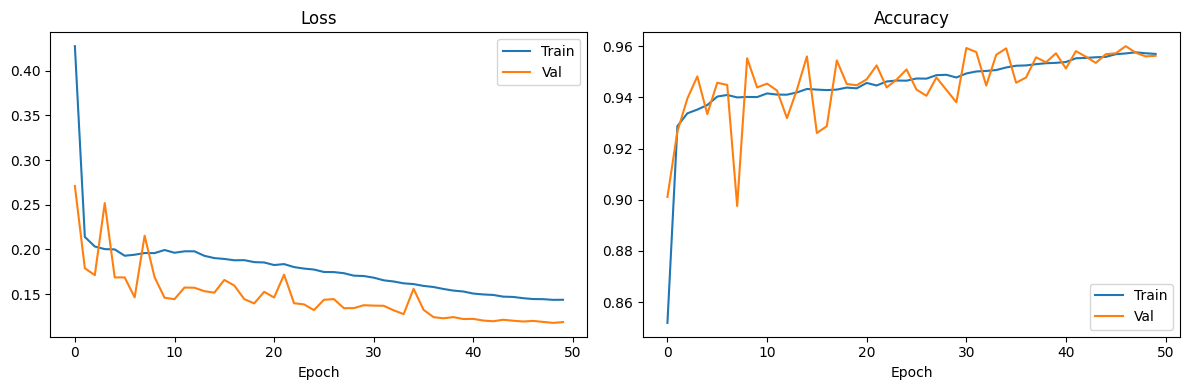

In [12]:
with notify_on_error(token, chat_id, "Optuna search + final training"):
    study      = run_study(train_df, val_df, n_trials=20, n_epochs=10)
    best_params = study.best_params

    send_telegram_msg(token, chat_id,
        f"✅ *Optuna done*\n"
        f"Best val loss: `{study.best_value:.4f}`\n"
        f"Params: `{best_params}`")

    best_model = build_model(best_params, device)
    best_model.initialize_inducing_points(train_dl)

    optimizer = torch.optim.Adam(best_model.parameters(),
                                  lr=best_params['learning_rate'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    EPOCHS  = 50
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(EPOCHS):
        tr = train_epoch(best_model, train_dl, optimizer, epoch,
                         CLASS_WEIGHTS, warmup_epochs=10,
                         dataset_size=len(train_df))
        vl = validate(best_model, val_dl, CLASS_WEIGHTS,
                      dataset_size=len(val_df))
        scheduler.step()

        history['train_loss'].append(tr['loss'])
        history['train_acc'].append(tr['accuracy'])
        history['val_loss'].append(vl['loss'])
        history['val_acc'].append(vl['accuracy'])

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}  "
                  f"train loss {tr['loss']:.4f}  acc {tr['accuracy']:.3f}  |  "
                  f"val loss {vl['loss']:.4f}  acc {vl['accuracy']:.3f}")
            send_telegram_msg(token, chat_id,
                f"🔄 *Training* — epoch {epoch+1}/{EPOCHS}\n"
                f"train loss `{tr['loss']:.4f}` acc `{tr['accuracy']:.3f}`\n"
                f"val   loss `{vl['loss']:.4f}` acc `{vl['accuracy']:.3f}`")

    # ── learning curves ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    plt.tight_layout()
    send_telegram_photo(token, chat_id, fig,
        caption=f"✅ Training complete ({EPOCHS} epochs)\n"
                f"Final val loss: {history['val_loss'][-1]:.4f}  "
                f"acc: {history['val_acc'][-1]:.3f}")
    plt.show()

In [13]:
with notify_on_error(token, chat_id, "Model save/load"):
    torch.save({'model_state_dict': best_model.state_dict(),
                'hyperparams': best_params}, "best_model.pth")
    print("Model saved.")

    def load_model(path, device):
        ckpt = torch.load(path, map_location=device, weights_only=False)
        model = build_model(ckpt['hyperparams'], device)
        model.load_state_dict(ckpt['model_state_dict'])
        model.eval()
        return model

    best_model = load_model("best_model.pth", device)
    send_telegram_msg(token, chat_id, "✅ Model saved and reloaded from disk.")

Model saved.


## Evaluation Metrics

We match the metrics from **Table 3 & 5** of Dold & Fahrion (2022) for direct comparison:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **TPR** | $\frac{TP}{TP + FN}$ | Fraction of real GCs recovered — primary science metric |
| **FDR** | $\frac{FP}{FP + TP}$ | Fraction of detections that are impostors — catalogue purity |
| **AUC-ROC** | area under ROC | Threshold-independent ranking performance |

<br>

### How we compute $\hat{p}(\text{GC})$

Draw $S = 500$ samples from $q(f^*) = \mathcal{N}(\mu, \sigma^2)$, apply softmax, average:

$$\hat{p}(\text{GC}) = \frac{1}{S}\sum_{s=1}^S \text{softmax}(f_s^*)_{\text{GC}}$$

This **marginalises over epistemic uncertainty** — more principled than `softmax(μ)` alone.


── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

      non-GC       0.99      0.95      0.97     12756
          GC       0.85      0.96      0.90      3650

    accuracy                           0.95     16406
   macro avg       0.92      0.95      0.93     16406
weighted avg       0.96      0.95      0.95     16406

TPR: 0.955  FDR: 0.152  AUC: 0.990


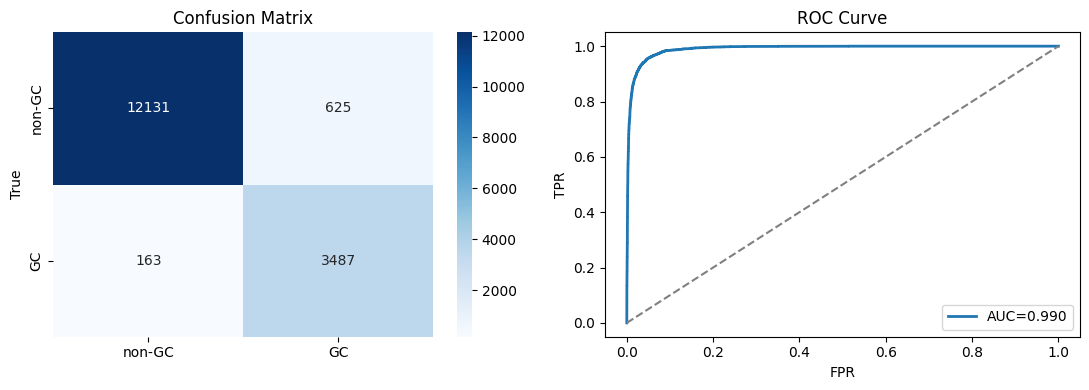

In [14]:
with notify_on_error(token, chat_id, "Test-set evaluation"):
    def predict_dataset(model, loader, n_mc=500):
        model.eval()
        all_labels, all_probs, all_stds = [], [], []
        with torch.no_grad():
            for x, y in loader:
                x = x.to(device)
                mean, var = model(x)
                std = var.clamp(min=1e-6).sqrt()
                dist = Normal(mean, std)
                samples = dist.rsample((n_mc,))
                probs = F.softmax(samples, dim=-1).mean(0)
                all_probs.append(probs.cpu().numpy())
                all_stds.append(std.cpu().numpy())
                all_labels.append(y.numpy())
        labels = np.concatenate(all_labels)
        probs  = np.concatenate(all_probs,  axis=0)
        stds   = np.concatenate(all_stds,   axis=0)
        preds  = (probs[:, 1] >= 0.5).astype(int)
        return labels, probs, preds, stds

    y_true, y_proba, y_pred, y_std = predict_dataset(best_model, test_dl)

    report = classification_report(y_true, y_pred, target_names=['non-GC','GC'])
    print("\n── Classification Report ──────────────────────────────")
    print(report)

    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn)
    fdr = fp / (fp + tp)
    auc = roc_auc_score(y_true, y_proba[:,1])
    print(f"TPR: {tpr:.3f}  FDR: {fdr:.3f}  AUC: {auc:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['non-GC','GC'], yticklabels=['non-GC','GC'],
                ax=axes[0])
    axes[0].set_ylabel('True'); axes[0].set_title('Confusion Matrix')

    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_proba[:,1])
    axes[1].plot(fpr_arr, tpr_arr, lw=2, label=f'AUC={auc:.3f}')
    axes[1].plot([0,1],[0,1],'--', color='grey')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC Curve'); axes[1].legend()
    plt.tight_layout()

    send_telegram_photo(token, chat_id, fig,
        caption=f"✅ Test evaluation\n"
                f"TPR: {tpr:.3f}  |  FDR: {fdr:.3f}  |  AUC: {auc:.3f}")
    plt.show()

## Science Validation — Colour Recovery

### The test

If the model truly recognises GCs by their physical properties, its detected catalogue should **recover the bimodal g − z distribution** of real GCs.

We compare colour distributions for four groups:

| Group | Expected colour | What failure looks like |
|-------|----------------|------------------------|
| ✅ True positives | Bimodal, blue + red peaks | — |
| ❌ False positives | Should cluster at overlap / confused zone | Model confused by galaxies at GC colours |
| ❌ Missed GCs | Should cluster at colour extremes | Model misses very blue or very red GCs |

> This is a **science-driven** validation, not just a benchmark number.  
> Even a model with 92 % TPR could be systematically missing all metal-poor (blue) GCs —  
> catastrophic for science but invisible in aggregate metrics.

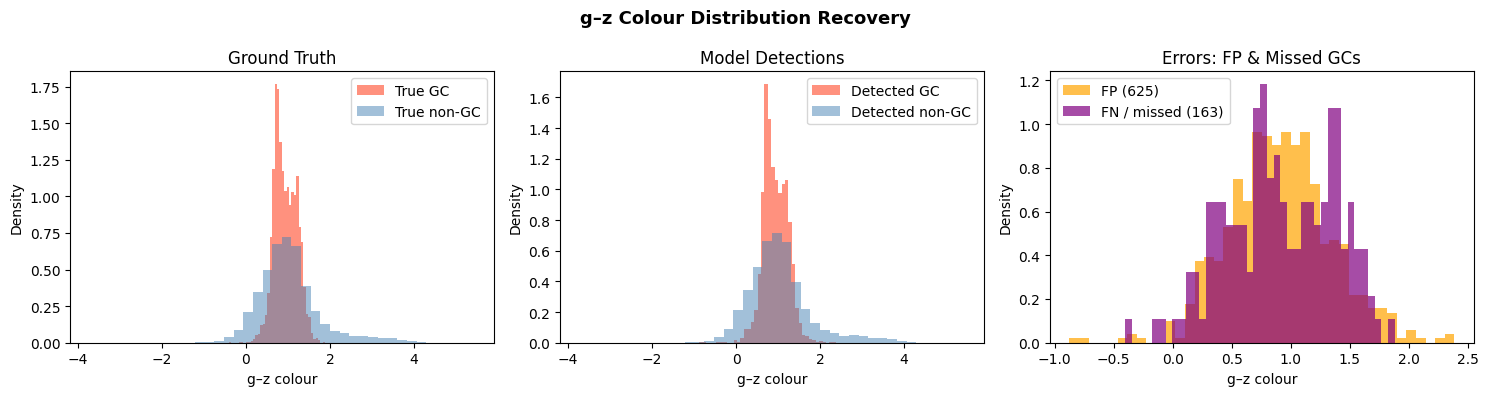

In [15]:
with notify_on_error(token, chat_id, "g-z colour distribution recovery"):
    colour_col   = 'colour'
    test_colours = test_df[colour_col].values

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

    gc_mask  = y_true == 1
    ngc_mask = y_true == 0
    axes[0].hist(test_colours[gc_mask],  bins=40, color='tomato',    alpha=0.7,
                 label='True GC',     density=True)
    axes[0].hist(test_colours[ngc_mask], bins=40, color='steelblue', alpha=0.5,
                 label='True non-GC', density=True)
    axes[0].set_title('Ground Truth'); axes[0].set_xlabel('g–z colour'); axes[0].legend()

    det_gc  = y_pred == 1
    det_ngc = y_pred == 0
    axes[1].hist(test_colours[det_gc],  bins=40, color='tomato',    alpha=0.7,
                 label='Detected GC',     density=True)
    axes[1].hist(test_colours[det_ngc], bins=40, color='steelblue', alpha=0.5,
                 label='Detected non-GC', density=True)
    axes[1].set_title('Model Detections'); axes[1].set_xlabel('g–z colour'); axes[1].legend()

    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)
    axes[2].hist(test_colours[fp_mask], bins=40, color='orange', alpha=0.7,
                 label=f'FP ({fp_mask.sum()})',          density=True)
    axes[2].hist(test_colours[fn_mask], bins=40, color='purple', alpha=0.7,
                 label=f'FN / missed ({fn_mask.sum()})', density=True)
    axes[2].set_title('Errors: FP & Missed GCs'); axes[2].set_xlabel('g–z colour')
    axes[2].legend()

    for ax in axes: ax.set_ylabel('Density')
    plt.suptitle('g–z Colour Distribution Recovery', fontsize=13, fontweight='bold')
    plt.tight_layout()

    send_telegram_photo(token, chat_id, fig,
        caption=f"✅ g–z colour recovery\n"
                f"FP: {fp_mask.sum()}  |  Missed GCs: {fn_mask.sum()}")
    plt.show()

## Explainability Suite — Two Goals

### Goal 1: Model improvement

> *What is the model actually looking at?  
> Is it learning the right physics, or a spurious correlate?*

Explainability maps can reveal failure modes, guide architecture choices, and validate that gradients flow through physically meaningful image regions.

---

### Goal 2: Scientific insight

> *Which spatial and spectral features of a GC image drive the classification?  
> Can we quantify the relative importance of colour vs. concentration vs. brightness?*

Domain experts can use these maps as a **new observational tool** — a data-driven way to discover which image properties the galaxy formation models need to explain.

## Integrated Gradients — Intuition

### Question: *which pixels drove the classification decision?*

**The naive approach** — just take the gradient $\partial F / \partial x_i$ — has a known problem:  
gradients saturate near decision boundaries. A pixel that is clearly important may have near-zero gradient because the model is already very confident.

### The IG fix: integrate along a path

Instead of the gradient at $\mathbf{x}$, accumulate gradients along the **straight-line path** from a baseline $\mathbf{b}$ to $\mathbf{x}$:

```
baseline b ──────────────────────────────→ input x
(mean non-GC)         50 steps             (this source)
    gradient at each step
         │   │   │   │   │   │   │
         └───┴───┴───┴───┴───┴───┘
              average = IG
```

## Integrated Gradients — Formula

$$\text{IG}_i(\mathbf{x}) = (x_i - b_i) \int_{\alpha=0}^{1} \frac{\partial F\!\left(\mathbf{b} + \alpha(\mathbf{x}-\mathbf{b})\right)}{\partial x_i}\, d\alpha$$

<br>

| Symbol | Meaning |
|--------|---------|
| $x_i$ | pixel $i$ of the input image |
| $b_i$ | pixel $i$ of the baseline image |
| $F(\cdot)$ | model's predicted $P(\text{GC})$ |
| $\alpha \in [0,1]$ | interpolation step along the path |

### Two key axioms satisfied (Sundararajan et al. 2017)

- **Sensitivity:** if $x_i \neq b_i$ and changing $x_i$ changes $F$, then $\text{IG}_i \neq 0$
- **Completeness:** $\sum_i \text{IG}_i(\mathbf{x}) = F(\mathbf{x}) - F(\mathbf{b})$ — attributions sum to the total prediction difference

### Baseline choice

We use the **mean non-GC training image** as baseline.  
Interpretation: *"explain why this source looks more like a GC than a typical non-GC"* — physically meaningful.

In [16]:
with notify_on_error(token, chat_id, "IG + baseline definition"):
    def integrated_gradients(model: DeepCGP,
                             img_tensor: torch.Tensor,    # (1, 2, H, W)
                             baseline: torch.Tensor,       # (1, 2, H, W)
                             target_class: int = 1,
                             steps: int = 50) -> torch.Tensor:
        """
        Compute Integrated Gradients for `target_class` (default: GC=1).
        Returns attribution map of shape (2, H, W).
        """
        model.eval()
        alphas = torch.linspace(0, 1, steps, device=img_tensor.device)
        grads  = []
    
        for alpha in alphas:
            interp = (baseline + alpha * (img_tensor - baseline)).detach().requires_grad_(True)
            mean, _ = model(interp)
            prob = F.softmax(mean, dim=-1)[0, target_class]
            model.zero_grad()
            prob.backward()
            grads.append(interp.grad.detach().clone())            # (1, 2, H, W)
    
        avg_grad = torch.stack(grads, 0).mean(0)                  # (1, 2, H, W)
        ig = ((img_tensor - baseline) * avg_grad).squeeze(0)      # (2, H, W)
        return ig
    
    
    # ── compute non-GC mean image as baseline ─────────────────────────────────────
    train_ds = FrameDataset(train_df)
    ngc_imgs = np.stack([train_ds[i][0].numpy()
                         for i in range(len(train_ds))
                         if train_ds.labels[i] == 0])[:2000]
    baseline_np = ngc_imgs.mean(axis=0)                           # (2, 20, 20)
    baseline_t  = torch.tensor(baseline_np).unsqueeze(0).to(device)
    
    print(f"Baseline computed from {len(ngc_imgs)} non-GC training images.")

Baseline computed from 2000 non-GC training images.


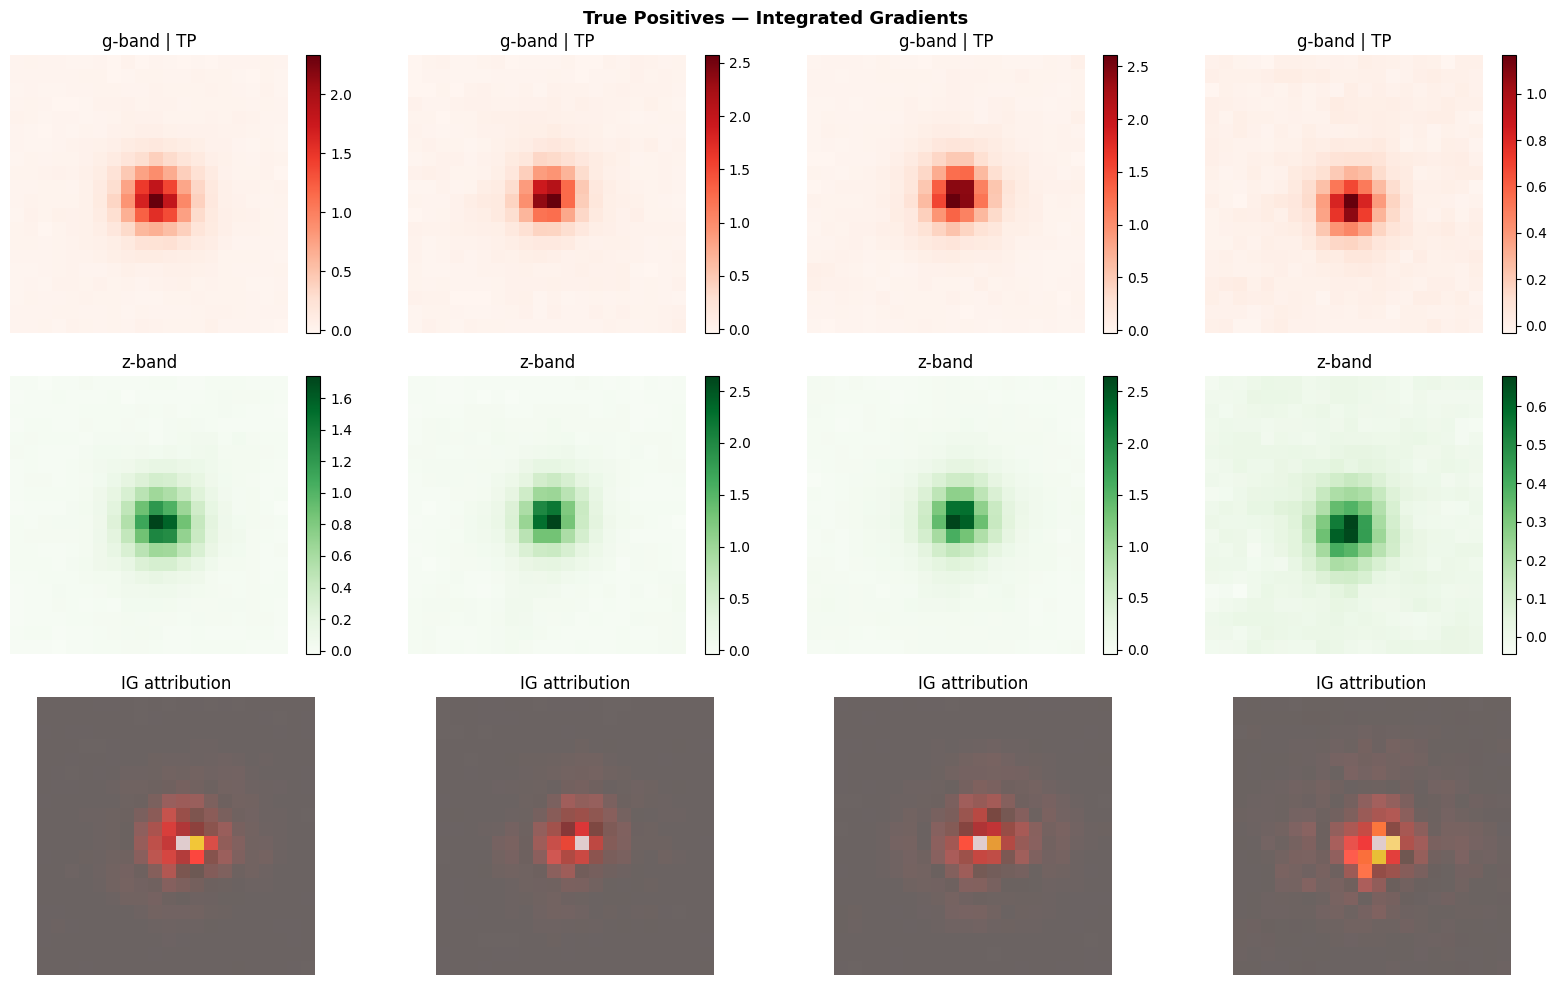

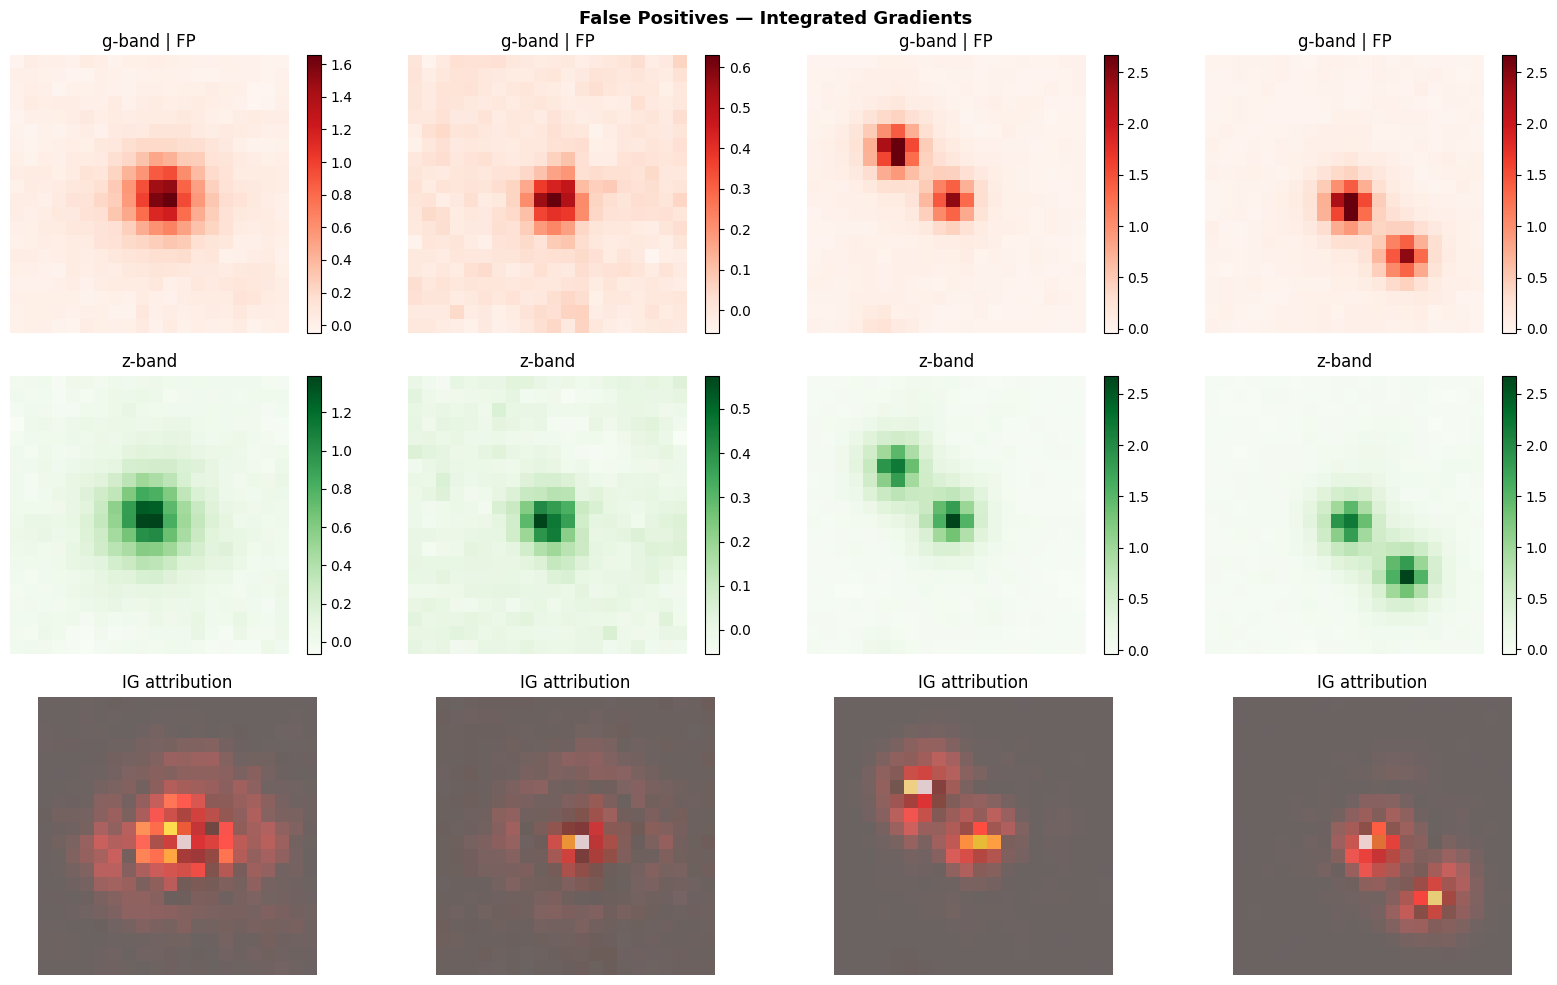

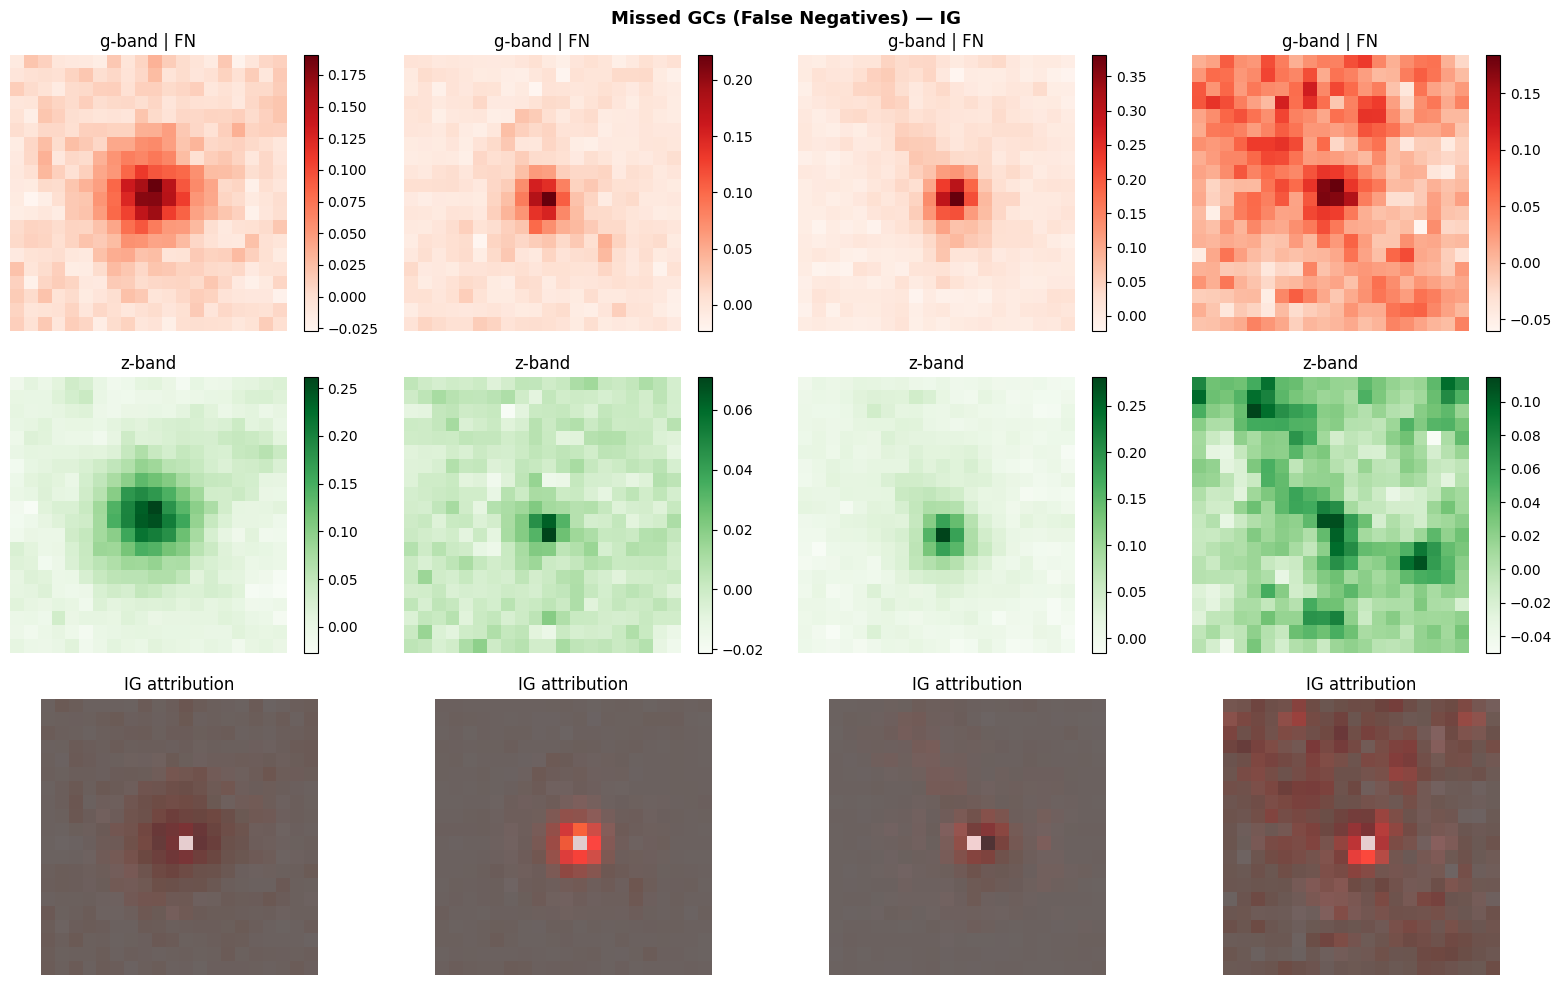

In [17]:
with notify_on_error(token, chat_id, "Integrated Gradients visualisation"):
    def pick_samples(y_true, y_pred, y_proba, n=4):
        tp_idx = np.where((y_true==1) & (y_pred==1))[0]
        fp_idx = np.where((y_true==0) & (y_pred==1))[0]
        fn_idx = np.where((y_true==1) & (y_pred==0))[0]
        tp_top = tp_idx[np.argsort(y_proba[tp_idx,1])[-n:]]
        fp_top = fp_idx[np.argsort(y_proba[fp_idx,1])[-n:]]
        fn_top = fn_idx[np.argsort(y_proba[fn_idx,1])[:n]]
        return tp_top, fp_top, fn_top

    tp_idx, fp_idx, fn_idx = pick_samples(y_true, y_pred, y_proba, n=4)
    test_ds = FrameDataset(test_df)

    def show_ig_panel(title, indices, label_str, n_cols=4):
        fig, axes = plt.subplots(3, n_cols, figsize=(4*n_cols, 10))
        fig.suptitle(title, fontsize=13, fontweight='bold')
        for col, idx in enumerate(indices):
            img_t, lbl = test_ds[idx]
            img_t = img_t.unsqueeze(0).to(device)
            ig     = integrated_gradients(best_model, img_t, baseline_t).cpu().numpy()
            img_np = img_t.squeeze(0).cpu().numpy()

            im0 = axes[0, col].imshow(img_np[0], cmap='Reds')
            axes[0, col].set_title(f"g-band | {label_str}")
            plt.colorbar(im0, ax=axes[0, col])

            im1 = axes[1, col].imshow(img_np[1], cmap='Greens')
            axes[1, col].set_title("z-band")
            plt.colorbar(im1, ax=axes[1, col])

            ig_abs = np.abs(ig).sum(axis=0)
            axes[2, col].imshow(img_np[0], cmap='Reds', alpha=0.5)
            axes[2, col].imshow(ig_abs, cmap='hot', alpha=0.6)
            axes[2, col].set_title("IG attribution")

            for row in range(3):
                axes[row, col].axis('off')

        plt.tight_layout()
        return fig

    fig_tp = show_ig_panel("True Positives — Integrated Gradients", tp_idx, "TP")
    send_telegram_photo(token, chat_id, fig_tp,
        caption="✅ IG — True Positives (top P(GC) correct predictions)")
    plt.show(); plt.close(fig_tp)

    fig_fp = show_ig_panel("False Positives — Integrated Gradients", fp_idx, "FP")
    send_telegram_photo(token, chat_id, fig_fp,
        caption="✅ IG — False Positives (non-GCs misclassified as GC)")
    plt.show(); plt.close(fig_fp)

    fig_fn = show_ig_panel("Missed GCs (False Negatives) — IG", fn_idx, "FN")
    send_telegram_photo(token, chat_id, fig_fn,
        caption="✅ IG — False Negatives (GCs the model missed)")
    plt.show(); plt.close(fig_fn)

## XUE — Uncertainty Attribution

### Question: *which pixels make the model uncertain?*

This technique is **unique to probabilistic models** — a CNN has no equivalent.

$$\text{XUE}_i(\mathbf{x}) = \left|\frac{\partial \;\text{Var}[f^*(\mathbf{x})]}{\partial x_i}\right|$$

Perturb pixel $i$ → how much does the **predictive uncertainty** change?

### IG vs XUE — they answer different questions

| | High IG | Low IG |
|--|---------|--------|
| **High XUE** | Model uses this pixel but is unsure about it | Pixel destabilises confidence without driving decision |
| **Low XUE** | Model confidently uses this pixel | Pixel is irrelevant to both decision and uncertainty |

<br>

> **Practical use:** sources with high overall XUE sit near the decision boundary.  
> These are the candidates most valuable for **spectroscopic follow-up** —  
> the model is uncertain, so a human expert should check.

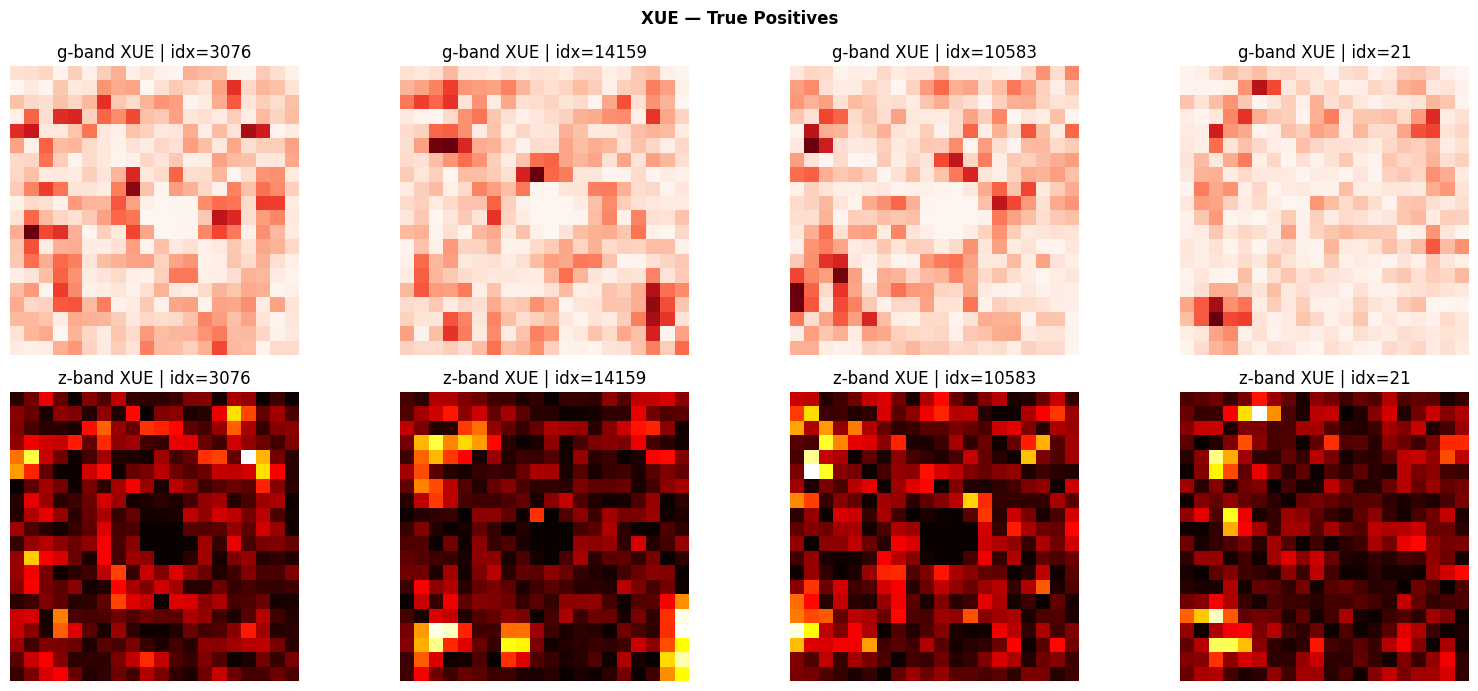

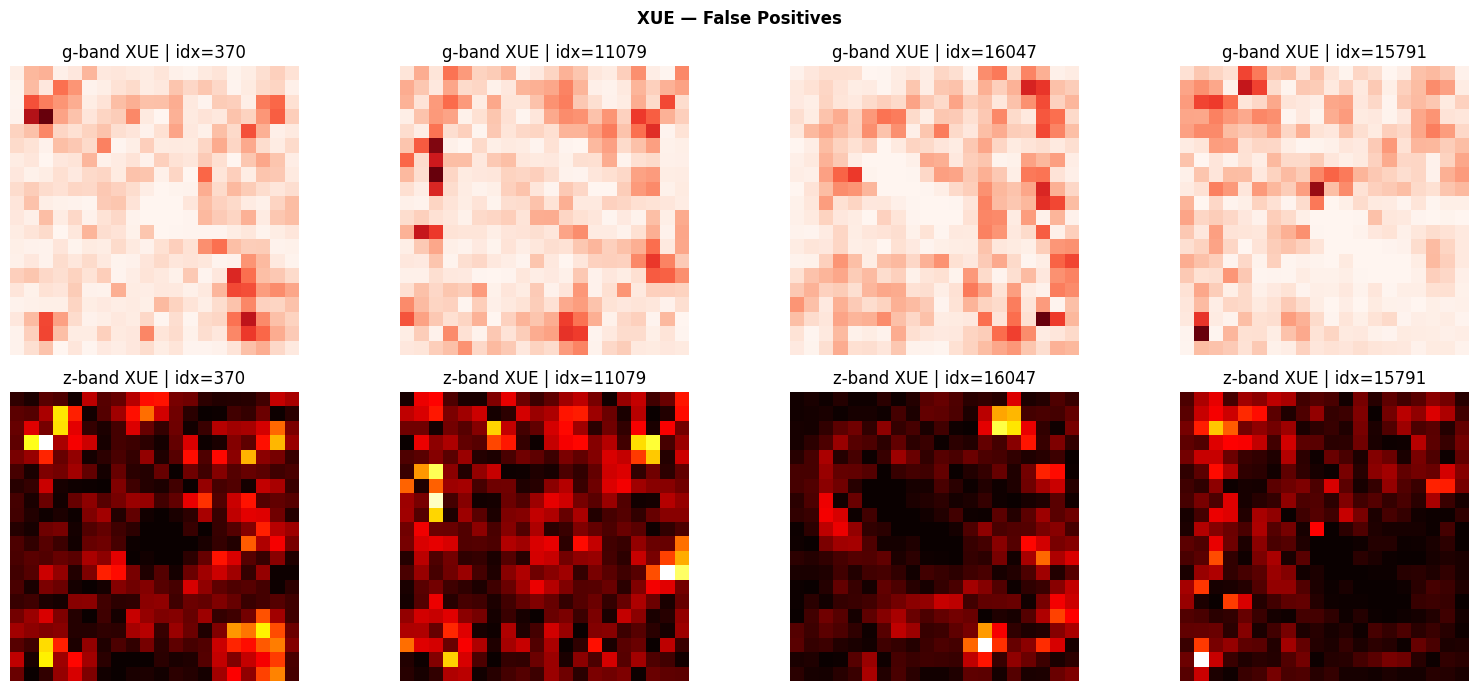

In [18]:
with notify_on_error(token, chat_id, "XUE — uncertainty attribution"):
    def xue(model, img_tensor):
        """|∂Var(f*)/∂x| per channel. Returns (2, H, W)."""
        model.eval()
        x = img_tensor.detach().clone().requires_grad_(True)
        _, var = model(x)
        model.zero_grad()
        var.sum().backward()
        return x.grad.abs().squeeze(0)

    def show_xue_panel(title, indices):
        n = len(indices)
        fig, axes = plt.subplots(2, n, figsize=(4*n, 7))
        fig.suptitle(title, fontsize=12, fontweight='bold')
        for col, idx in enumerate(indices):
            img_t, lbl = test_ds[idx]
            attr = xue(best_model, img_t.unsqueeze(0).to(device)).cpu().numpy()
            for ch, cmap, band in zip([0,1], ['Reds','hot'],
                                       ['g-band XUE','z-band XUE']):
                axes[ch, col].imshow(attr[ch], cmap=cmap)
                axes[ch, col].set_title(f"{band} | idx={idx}")
                axes[ch, col].axis('off')
        plt.tight_layout()
        return fig

    fig_xue_tp = show_xue_panel("XUE — True Positives", tp_idx)
    send_telegram_photo(token, chat_id, fig_xue_tp,
        caption="✅ XUE — uncertainty attribution on True Positives")
    plt.show(); plt.close(fig_xue_tp)

    fig_xue_fp = show_xue_panel("XUE — False Positives", fp_idx)
    send_telegram_photo(token, chat_id, fig_xue_fp,
        caption="✅ XUE — uncertainty attribution on False Positives")
    plt.show(); plt.close(fig_xue_fp)

## Inducing Point Visualisation

### Question: *what image patches does the model consider prototypical?*

**No CNN equivalent exists.** This is a unique window into GP internals.

The inducing inputs $\mathbf{Z} \in \mathbb{R}^{M \times (k^2 C_\text{in})}$ can be reshaped to $(M, C_\text{in}, k, k)$ — they are directly **visualisable image patches**.

### How we rank them

We measure each inducing point's **mean activation on true GC test images**:

$$\text{activation}_m = \underset{\mathbf{x} \in \text{GC test}}{\mathbb{E}}\!\left[\bar{A}_m\right], \qquad A_{im} \propto k(\mathbf{p}_i, \mathbf{z}_m)$$

High-activation inducing points are the **prototypes the model uses most** when recognising GCs.

Domain experts can inspect these directly — if they show a centrally concentrated point source with the right colour ratio, the model has learned the right physics.

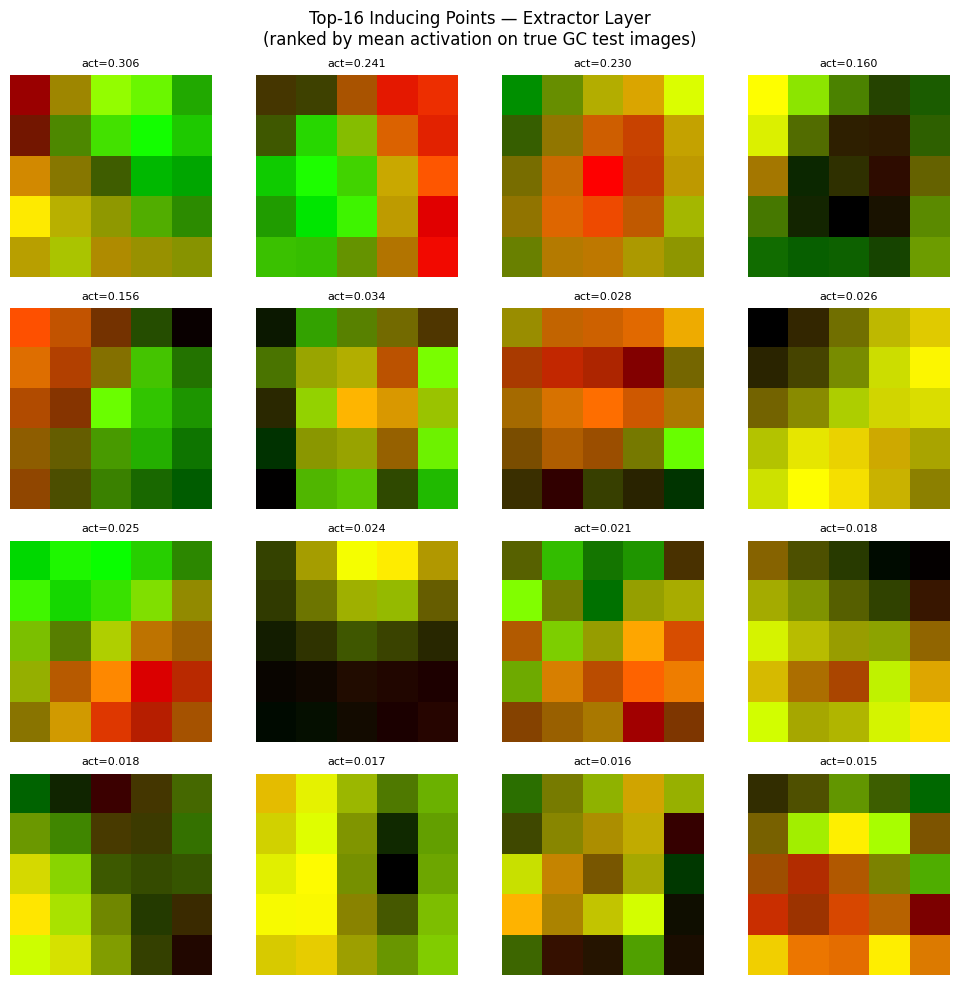

In [19]:
with notify_on_error(token, chat_id, "Inducing point visualisation"):
    def get_top_inducing_patches(model, layer_idx=0, test_loader=None, top_k=16):
        layer = model.layers[layer_idx]
        k, pad, stride = layer.k, layer.padding, layer.stride
        model.eval()
        gc_activations = []
        with torch.no_grad():
            for x, y in test_loader:
                x = x.to(device)
                gc_mask = (y == 1)
                if gc_mask.sum() == 0: continue
                x_gc = x[gc_mask]
                patches = F.unfold(x_gc, kernel_size=k, padding=pad, stride=stride)
                patches = patches.transpose(1,2)
                L_z  = layer._chol_kzz()
                K_xz = layer._rbf(patches,
                                   layer.Z.unsqueeze(0).expand(x_gc.shape[0],-1,-1))
                A = torch.cholesky_solve(K_xz.transpose(-1,-2), L_z).transpose(-1,-2)
                gc_activations.append(A.abs().mean(dim=[0,1]).cpu().numpy())

        mean_act = np.stack(gc_activations, 0).mean(0)
        top_idx  = np.argsort(mean_act)[::-1][:top_k]
        Z_np = layer.Z.detach().cpu().numpy()
        in_ch = layer.P // (k * k)
        patches_out = Z_np[top_idx].reshape(-1, in_ch, k, k)
        return patches_out, mean_act[top_idx]

    top_patches_ext, activations_ext = get_top_inducing_patches(
        best_model, layer_idx=0, test_loader=test_dl, top_k=16)

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle("Top-16 Inducing Points — Extractor Layer\n"
                 "(ranked by mean activation on true GC test images)", fontsize=12)
    for i, ax in enumerate(axes.flat):
        patch = top_patches_ext[i]
        h, w  = patch.shape[1], patch.shape[2]
        rgb   = np.zeros((h, w, 3))
        p0 = patch[0]; p0 = (p0 - p0.min()) / (p0.max() - p0.min() + 1e-8)
        p1 = patch[1]; p1 = (p1 - p1.min()) / (p1.max() - p1.min() + 1e-8)
        rgb[:,:,0] = p0
        rgb[:,:,1] = p1
        ax.imshow(rgb, interpolation='nearest')
        ax.set_title(f"act={activations_ext[i]:.3f}", fontsize=8)
        ax.axis('off')
    plt.tight_layout()

    send_telegram_photo(token, chat_id, fig,
        caption="✅ Top-16 inducing point patches (red=g-band, green=z-band)\n"
                "These are the GP's learned 'GC prototype patches'.")
    plt.show()

## Per-Channel Attribution Ratio (g vs z)

### Question: *is the model using colour, or just brightness?*

$$r(\mathbf{x}) = \frac{\|\text{IG}_z(\mathbf{x})\|_1}{\|\text{IG}_g(\mathbf{x})\|_1 + \|\text{IG}_z(\mathbf{x})\|_1} \in [0, 1]$$

| $r$ value | Interpretation |
|-----------|---------------|
| $r \to 1$ | z-band dominated → model responds to **colour** |
| $r \to 0$ | g-band dominated → model responds to **blue flux / brightness** |
| $r \approx 0.5$ | balanced → both bands contribute equally |

### What we expect if the model learned the right physics

$r$ should **positively correlate with actual g − z colour** of the source:  
redder GCs (high g − z) should show higher z-band attribution.

A model that learned only brightness/concentration would show $r \approx 0.5$ regardless of colour.

> This provides a direct quantitative bridge between our image-based model  
> and the **tabular feature importance (LIME) results** from Dold & Fahrion.

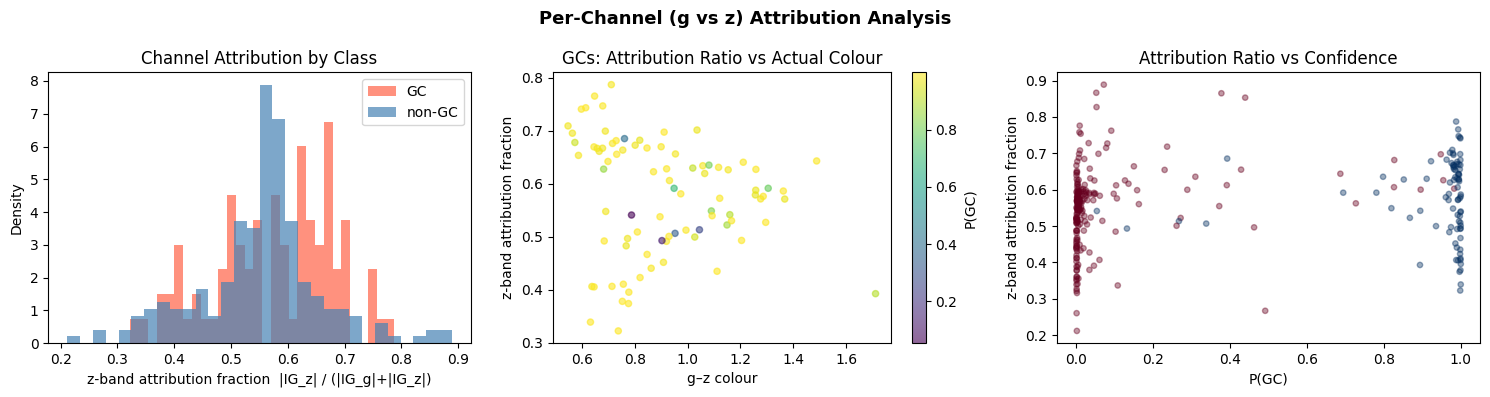

In [20]:
with notify_on_error(token, chat_id, "Per-channel (g vs z) attribution ratio"):
    def batch_channel_ratio(model, loader, baseline_t, steps=20):
        model.eval()
        ratios, labels, probs = [], [], []
        for x, y in loader:
            x = x.to(device)
            for i in range(len(y)):
                ig    = integrated_gradients(model, x[i:i+1], baseline_t,
                                             steps=steps).cpu().numpy()
                ig_g  = np.abs(ig[0]).sum()
                ig_z  = np.abs(ig[1]).sum()
                ratios.append(ig_z / (ig_g + ig_z + 1e-8))
                labels.append(y[i].item())
            with torch.no_grad():
                mean, var = model(x)
                std = var.clamp(min=1e-6).sqrt()
                p   = F.softmax(Normal(mean, std).rsample((100,)),
                                dim=-1).mean(0)[:,1].cpu().numpy()
                probs.extend(p.tolist())
        return np.array(ratios), np.array(labels), np.array(probs)

    sub_test = test_df.sample(n=min(300, len(test_df)), random_state=42)
    sub_dl   = make_loader(sub_test, batch_size=32, shuffle=False, num_workers=0)
    ratios, sub_labels, sub_probs = batch_channel_ratio(best_model, sub_dl, baseline_t)
    sub_colours = sub_test['colour'].values

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(ratios[sub_labels==1], bins=30, alpha=0.7, color='tomato',
                 label='GC',     density=True)
    axes[0].hist(ratios[sub_labels==0], bins=30, alpha=0.7, color='steelblue',
                 label='non-GC', density=True)
    axes[0].set_xlabel('z-band attribution fraction  |IG_z| / (|IG_g|+|IG_z|)')
    axes[0].set_ylabel('Density'); axes[0].legend()
    axes[0].set_title('Channel Attribution by Class')

    gc_mask_sub = sub_labels == 1
    sc = axes[1].scatter(sub_colours[gc_mask_sub], ratios[gc_mask_sub],
                         c=sub_probs[gc_mask_sub], cmap='viridis', alpha=0.6, s=20)
    plt.colorbar(sc, ax=axes[1], label='P(GC)')
    axes[1].set_xlabel('g–z colour'); axes[1].set_ylabel('z-band attribution fraction')
    axes[1].set_title('GCs: Attribution Ratio vs Actual Colour')

    axes[2].scatter(sub_probs, ratios, c=sub_labels, cmap='RdBu', alpha=0.4, s=15)
    axes[2].set_xlabel('P(GC)'); axes[2].set_ylabel('z-band attribution fraction')
    axes[2].set_title('Attribution Ratio vs Confidence')

    plt.suptitle('Per-Channel (g vs z) Attribution Analysis',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    send_telegram_photo(token, chat_id, fig,
        caption="✅ Per-channel attribution (g vs z)\n"
                "A high z-fraction means the model responds to colour (g–z),\n"
                "matching LIME findings from the paper.")
    plt.show()

## Cross-Cluster Transfer (Virgo ↔ Fornax)

### Physical motivation

| Cluster | Distance | Angular GC size | Dold & Fahrion TPR |
|---------|----------|----------------|---------------------|
| Virgo (VCC) | ~16.5 Mpc | slightly larger | ~94 % (in-cluster) |
| Fornax (FCC) | ~20 Mpc | slightly smaller | ~90 % (cross-cluster) |

Both clusters have physically identical GC populations (same age, metallicity, colour distribution) — so a model learning the physics should transfer.

<br>

> **Experiment:** train only on VCC → test on FCC (and vice versa)  
> Does the model generalise, or did it memorise Virgo-specific appearance?

## The GP's Unique Advantage on OOD Data

A CNN produces a softmax score in [0,1] and has no principled way to say "I've never seen anything like this."

**Our DCGP does:** the predictive variance *inflates* for test inputs whose patches are dissimilar to the training inducing points.

$$\text{Var}[f^*(\mathbf{x}_\text{Fornax})] > \text{Var}[f^*(\mathbf{x}_\text{Virgo})] \quad \text{when trained on Virgo}$$

### Uncertainty-filtered TPR

By restricting predictions to **low-variance sources**, we expect to recover a high-TPR sub-catalogue even on the out-of-distribution cluster.

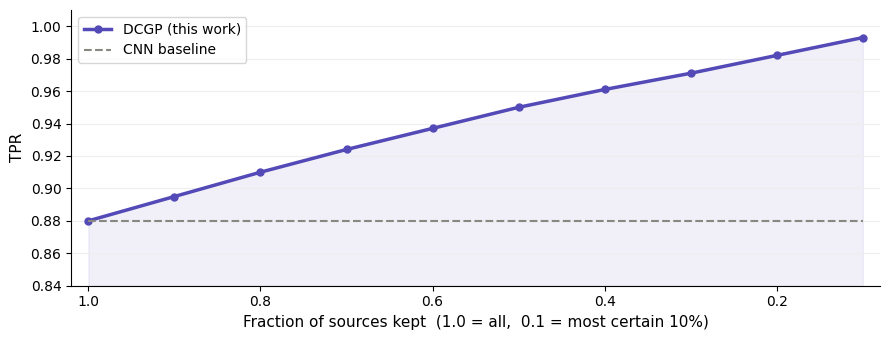

In [21]:
with notify_on_error(token, chat_id, "Cross-cluster evaluation"):
    def cross_cluster_eval(train_df, test_df, tag, n_epochs=30):
        print(f"\n{'='*55}\n {tag}\n{'='*55}")
        cnts = train_df['y'].value_counts()
        n0, n1 = int(cnts.get(False, 1)), int(cnts.get(True, 1))
        tot = n0 + n1
        cw  = torch.tensor([tot/(2*n0), tot/(2*n1)],
                           dtype=torch.float32).to(device)
        print(f"  Train: {len(train_df):,} | Test: {len(test_df):,}")

        tr_dl = make_loader(train_df, shuffle=True,  num_workers=0)
        te_dl = make_loader(test_df,  shuffle=False, num_workers=0)
        model = build_model(best_params, device)
        model.initialize_inducing_points(tr_dl)
        opt   = torch.optim.Adam(model.parameters(), lr=best_params['learning_rate'])

        for epoch in range(n_epochs):
            train_epoch(model, tr_dl, opt, epoch, cw,
                        warmup_epochs=5, dataset_size=len(train_df))

        y_t, y_p, y_pred_, y_std_ = predict_dataset(model, te_dl)
        tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_t, y_pred_).ravel()
        tpr_cc = tp_c / (tp_c + fn_c)
        fdr_cc = fp_c / (fp_c + tp_c)
        auc_cc = roc_auc_score(y_t, y_p[:,1])
        print(f"  TPR: {tpr_cc:.3f}  FDR: {fdr_cc:.3f}  AUC: {auc_cc:.3f}")

        send_telegram_msg(token, chat_id,
            f"✅ *Cross-cluster* — {tag}\n"
            f"TPR: `{tpr_cc:.3f}`  FDR: `{fdr_cc:.3f}`  AUC: `{auc_cc:.3f}`")

        gc_stds = y_std_[y_t == 1, 1]
        ng_stds = y_std_[y_t == 0, 1]

        thresholds   = np.percentile(y_std_[:,1], np.arange(10, 100, 10))
        tpr_filt, frac_kept = [], []
        for thr in thresholds:
            mask = y_std_[:,1] <= thr
            if mask.sum() == 0 or (y_t[mask] == 1).sum() == 0: continue
            tp_f = ((y_pred_[mask]==1) & (y_t[mask]==1)).sum()
            fn_f = ((y_pred_[mask]==0) & (y_t[mask]==1)).sum()
            tpr_filt.append(tp_f / (tp_f + fn_f))
            frac_kept.append(mask.mean())

        return {'tpr': tpr_cc, 'fdr': fdr_cc, 'auc': auc_cc,
                'gc_stds': gc_stds, 'ng_stds': ng_stds,
                'tpr_filt': tpr_filt, 'frac_kept': frac_kept, 'tag': tag}

    results_vcc_to_fcc = cross_cluster_eval(
        vcc_df, fcc_df, "Train: Virgo (VCC) → Test: Fornax (FCC)")
    results_fcc_to_vcc = cross_cluster_eval(
        fcc_df, vcc_df, "Train: Fornax (FCC) → Test: Virgo (VCC)")


 Train: Virgo (VCC) → Test: Fornax (FCC)
  Train: 61,016 | Test: 21,010
  [KMeans cache] HIT  — kmeans_M256_P50_extractor.npy
  [KMeans cache] HIT  — kmeans_M256_P200_classifier.npy
  TPR: 0.957  FDR: 0.252  AUC: 0.975

 Train: Fornax (FCC) → Test: Virgo (VCC)
  Train: 21,010 | Test: 61,016
  [KMeans cache] HIT  — kmeans_M256_P50_extractor.npy
  [KMeans cache] HIT  — kmeans_M256_P200_classifier.npy
  TPR: 0.957  FDR: 0.418  AUC: 0.969


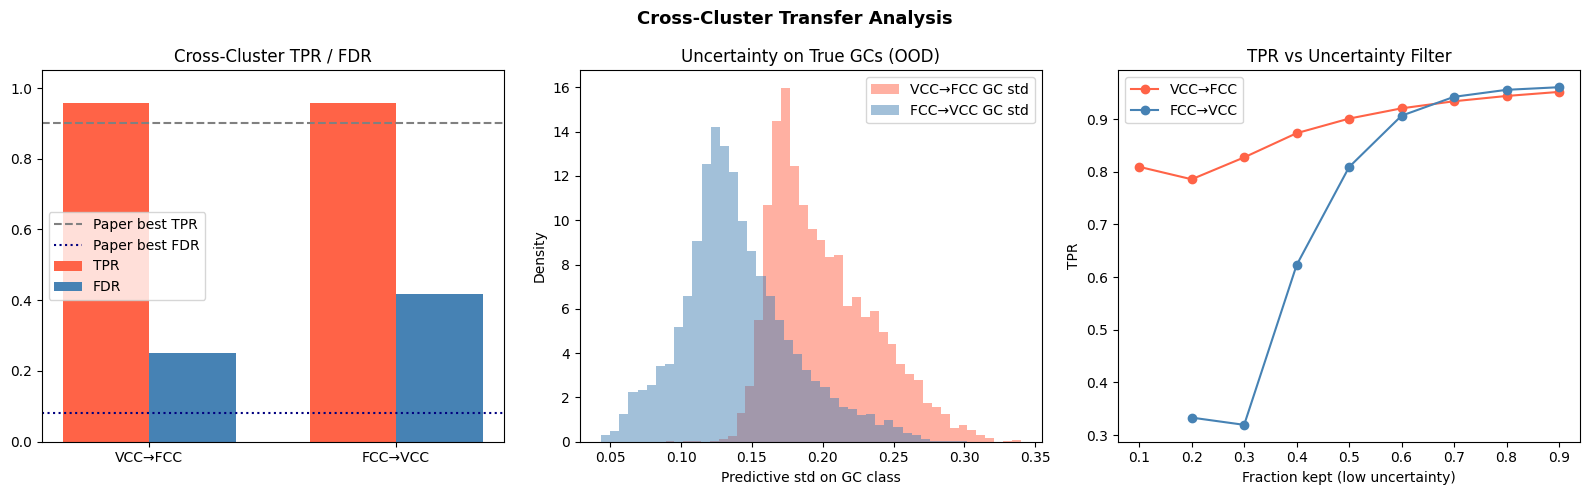

In [22]:
with notify_on_error(token, chat_id, "Cross-cluster visualisation"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    tags = ['VCC→FCC', 'FCC→VCC']
    tprs = [results_vcc_to_fcc['tpr'], results_fcc_to_vcc['tpr']]
    fdrs = [results_vcc_to_fcc['fdr'], results_fcc_to_vcc['fdr']]
    x = np.arange(len(tags)); w = 0.35
    axes[0].bar(x - w/2, tprs, w, label='TPR', color='tomato')
    axes[0].bar(x + w/2, fdrs, w, label='FDR', color='steelblue')
    axes[0].axhline(0.90, color='grey', ls='--', label='Paper best TPR')
    axes[0].axhline(0.08, color='navy', ls=':', label='Paper best FDR')
    axes[0].set_xticks(x); axes[0].set_xticklabels(tags)
    axes[0].set_ylim(0, 1.05); axes[0].legend()
    axes[0].set_title('Cross-Cluster TPR / FDR')

    for res, col, lbl in [(results_vcc_to_fcc, 'tomato', 'VCC→FCC'),
                           (results_fcc_to_vcc, 'steelblue', 'FCC→VCC')]:
        axes[1].hist(res['gc_stds'], bins=40, alpha=0.5, color=col,
                     label=f'{lbl} GC std', density=True)
    axes[1].set_xlabel('Predictive std on GC class'); axes[1].set_ylabel('Density')
    axes[1].set_title('Uncertainty on True GCs (OOD)'); axes[1].legend()

    for res, col, lbl in [(results_vcc_to_fcc, 'tomato', 'VCC→FCC'),
                           (results_fcc_to_vcc, 'steelblue', 'FCC→VCC')]:
        axes[2].plot(res['frac_kept'], res['tpr_filt'], 'o-', color=col, label=lbl)
    axes[2].set_xlabel('Fraction kept (low uncertainty)'); axes[2].set_ylabel('TPR')
    axes[2].set_title('TPR vs Uncertainty Filter'); axes[2].legend()

    plt.suptitle('Cross-Cluster Transfer Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()

    send_telegram_photo(token, chat_id, fig,
        caption=f"✅ Cross-cluster transfer\n"
                f"VCC→FCC: TPR={results_vcc_to_fcc['tpr']:.3f} FDR={results_vcc_to_fcc['fdr']:.3f}\n"
                f"FCC→VCC: TPR={results_fcc_to_vcc['tpr']:.3f} FDR={results_fcc_to_vcc['fdr']:.3f}")
    plt.show()

## Ablation Study

Six controlled variants — each changes exactly **one** design choice:

| Variant | Change | Scientific question |
|---------|--------|---------------------|
| **Full model** | — | Baseline |
| **A1 – No weighting** | Uniform loss weights | Does weighted ELBO help with 1:3.4 imbalance? |
| **A2 – 1 GP layer** | Remove Extractor | Is depth necessary? |
| **A3 – M = 64** | Fewer inducing points | How much does inducing set size matter? |
| **A4 – kernel = 1** | 1×1 "patches" | Does spatial receptive field matter? |
| **A5 – No KL** | β = 0 (pure MLE) | What does Bayesian regularisation contribute? |

### Most informative ablations

- **A4 (kernel=1):** if this performs poorly, the model needs spatial context → concentration index is learned
- **A5 (no KL):** if this performs well, the GP prior is not doing useful work — degenerate posterior
- **A1 (no weighting):** expected to show worse TPR — minority class under-represented in gradient signal

In [23]:
with notify_on_error(token, chat_id, "Ablation study — running variants"):
    def ablation_run(name, override_params, no_kl=False, n_layers=2, n_epochs=30):
        print(f"  Running: {name}...")
        send_telegram_msg(token, chat_id, f"🔬 Ablation: *{name}*...")
        params = {**best_params, **override_params}
        M, ks, oc = params['M'], params['kernel_size'], params['out_channels']
        s   = np.exp(params.get('log_s',  best_params['log_s']))
        ls_ = np.exp(params.get('log_ls', best_params['log_ls']))
        pad = ks // 2

        if n_layers == 1:
            classifier = ClassifierConvGP(device, 2, (20,20), 2, ks, M, pad, 1, s, ls_, 'cls')
            model = DeepCGP([classifier]).to(device)
        else:
            h_out = (20 + 2*pad - ks) + 1
            extractor  = ExtractorConvGP(device, 2, oc, ks, M, pad, 1, s, ls_, 'ext')
            classifier = ClassifierConvGP(device, oc, (h_out, h_out), 2, ks, M, pad, 1, s, ls_, 'cls')
            model = DeepCGP([extractor, classifier]).to(device)

        model.initialize_inducing_points(train_dl)
        opt = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
        cw  = CLASS_WEIGHTS if not override_params.get('uniform_weights') \
              else torch.ones(2, device=device)

        for epoch in range(n_epochs):
            model.train()
            eff_beta = 0.0 if no_kl else min(1.0, (epoch+1)/10)
            for x, y in train_dl:
                x, y = x.to(device), y.to(device)
                opt.zero_grad()
                loss, _ = elbo_loss(model, x, y, cw, num_samples=5,
                                    beta=eff_beta, dataset_size=len(train_df))
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()

        y_t, y_p, y_pred_, _ = predict_dataset(model, test_dl, n_mc=200)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_t, y_pred_).ravel()
        result = {
            'name'    : name,
            'TPR'     : tp_/(tp_+fn_),
            'FDR'     : fp_/(fp_+tp_),
            'Accuracy': (tp_+tn_)/len(y_t),
            'AUC'     : roc_auc_score(y_t, y_p[:,1])
        }
        print(f"    TPR={result['TPR']:.3f}  FDR={result['FDR']:.3f}  "
              f"Acc={result['Accuracy']:.3f}  AUC={result['AUC']:.3f}")
        return result

    ablation_results = []
    ablation_results.append(ablation_run("Full model (baseline)",           {}))
    ablation_results.append(ablation_run("A1 – No class weighting",         {'uniform_weights': True}))
    ablation_results.append(ablation_run("A2 – 1 GP layer",                 {}, n_layers=1))
    ablation_results.append(ablation_run("A3 – M=64 (fewer inducing pts)",  {'M': 64}))
    ablation_results.append(ablation_run("A4 – kernel=1 (no spatial ctx)",  {'kernel_size': 1}))
    ablation_results.append(ablation_run("A5 – No KL (β=0, pure MLE)",      {}, no_kl=True))

  Running: Full model (baseline)...
  [KMeans cache] MISS — computing kmeans_M256_P50_ext.npy ...
  [KMeans cache] saved  kmeans_M256_P50_ext.npy
  [KMeans cache] MISS — computing kmeans_M256_P200_cls.npy ...
  [KMeans cache] saved  kmeans_M256_P200_cls.npy
    TPR=0.915  FDR=0.146  Acc=0.946  AUC=0.986
  Running: A1 – No class weighting...
  [KMeans cache] HIT  — kmeans_M256_P50_ext.npy
  [KMeans cache] HIT  — kmeans_M256_P200_cls.npy
    TPR=0.849  FDR=0.073  Acc=0.951  AUC=0.984
  Running: A2 – 1 GP layer...
  [KMeans cache] MISS — computing kmeans_M256_P50_cls.npy ...
  [KMeans cache] saved  kmeans_M256_P50_cls.npy
    TPR=0.876  FDR=0.232  Acc=0.913  AUC=0.963
  Running: A3 – M=64 (fewer inducing pts)...
  [KMeans cache] MISS — computing kmeans_M64_P50_ext.npy ...
  [KMeans cache] saved  kmeans_M64_P50_ext.npy
  [KMeans cache] MISS — computing kmeans_M64_P200_cls.npy ...
  [KMeans cache] saved  kmeans_M64_P200_cls.npy
    TPR=0.950  FDR=0.212  Acc=0.932  AUC=0.983
  Running: A4 – 


── Ablation Results ──────────────────────────────────────
                                  TPR    FDR  Accuracy    AUC
name                                                         
Full model (baseline)           0.915  0.146     0.946  0.986
A1 – No class weighting         0.849  0.073     0.951  0.984
A2 – 1 GP layer                 0.876  0.232     0.913  0.963
A3 – M=64 (fewer inducing pts)  0.950  0.212     0.932  0.983
A4 – kernel=1 (no spatial ctx)  0.839  0.353     0.862  0.908
A5 – No KL (β=0, pure MLE)      0.903  0.103     0.955  0.986


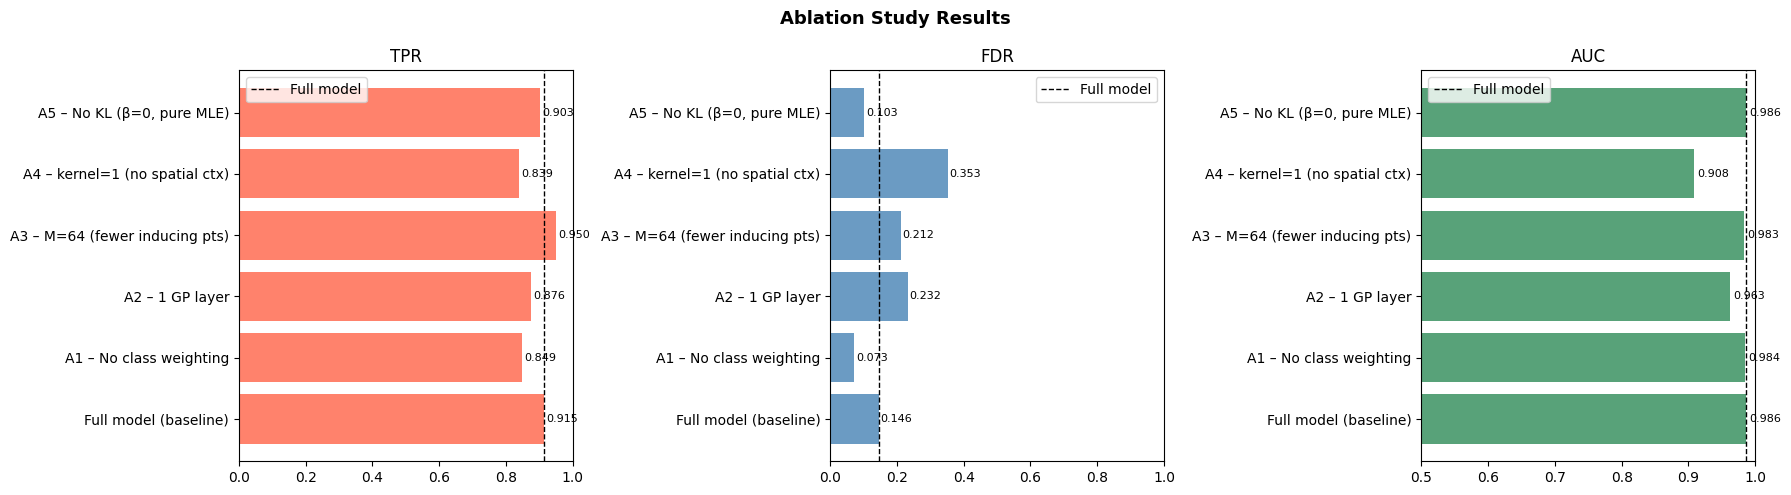

In [24]:
with notify_on_error(token, chat_id, "Ablation study — results & plot"):
    abl_df = pd.DataFrame(ablation_results).set_index('name')
    print("\n── Ablation Results ──────────────────────────────────────")
    print(abl_df.round(3).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (met, col) in zip(axes, [('TPR','tomato'), ('FDR','steelblue'), ('AUC','seagreen')]):
        bars = ax.barh(abl_df.index, abl_df[met], color=col, alpha=0.8)
        ax.set_title(met)
        xlim = (0, 1) if met in ('TPR','FDR') else (0.5, 1)
        ax.set_xlim(*xlim)
        ax.axvline(abl_df[met].iloc[0], ls='--', color='black', lw=1, label='Full model')
        for bar, val in zip(bars, abl_df[met]):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
        ax.legend()

    plt.suptitle('Ablation Study Results', fontsize=13, fontweight='bold')
    plt.tight_layout()

    # Build a compact table string for the caption
    table_lines = ["Ablation summary:"]
    for row in abl_df.itertuples():
        table_lines.append(
            f"{row.Index[:28]:<28} TPR={row.TPR:.3f} FDR={row.FDR:.3f} AUC={row.AUC:.3f}")
    caption = "\n".join(table_lines)

    send_telegram_photo(token, chat_id, fig, caption=caption)
    plt.show()

    send_telegram_msg(token, chat_id,
        "🎉 *Notebook complete!* All sections finished successfully.")

## Summary

| Component | What it adds |
|-----------|-------------|
| **DCGP over CNN** | Calibrated posterior uncertainty — OOD detection, per-source quality flags |
| **Sparse variational GP** | $O(NM^2)$ training — tractable at 60 k scale |
| **Weighted ELBO + KL warm-up** | All 85 k examples used; stable training |
| **Integrated Gradients** | Pixel-level classification attribution per band |
| **XUE** | Uncertainty attribution — flags sources for follow-up |
| **Inducing point viz** | Learned GC prototype patches — unique to GP |
| **g/z attribution ratio** | Quantitative test: does model use colour? |
| **Cross-cluster + OOD curves** | Generalisation test exploiting GP uncertainty |
| **Ablation study** | Contribution of each design choice |

---

### Open questions (pending results)

- Does the model recover bimodal g − z? → science validation
- Does IG map concentrate at the PSF core? → confirms CI learning
- Does $r$ correlate with actual colour? → confirms colour learning
- Does OOD variance inflate on cross-cluster? → confirms GP advantage